# Huấn Luyện Mô Hình Dự Đoán Thất Bại Thử Nghiệm Lâm Sàng Ung Thư

**Notebook 05: Huấn luyện và Đánh giá Mô hình**

#### 1. Câu hỏi

>Liệu chúng ta có thể dự báo sớm nguy cơ thất bại của các thử nghiệm lâm sàng ung thư chỉ dựa trên các đặc điểm thiết kế ban đầu (pre-trial features) hay không? Và đâu là những yếu tố quyết định dẫn đến dự báo đó?

**Mục tiêu:** Xây dựng mô hình phân loại nhị phân (Binary Classification) để dự đoán kết quả thử nghiệm lâm sàng ung thư dựa trên 34 đặc trưng pre-trial, với biến mục tiêu là **label_binary** (1 = Thành công/COMPLETED, 0 = Thất bại/TERMINATED hoặc WITHDRAWN).

#### 2. Động cơ nghiên cứu
Thử nghiệm lâm sàng ung thư có tỷ lệ thất bại rất cao, dao động từ 70% đến 90%, với chi phí trung bình từ 50 đến 100 triệu USD cho mỗi thử nghiệm. Việc dự đoán sớm nguy cơ thất bại sẽ giúp các công ty dược phẩm và nhà nghiên cứu đưa ra quyết định Go/No-Go kịp thời, từ đó tiết kiệm đáng kể nguồn lực tài chính và nhân lực.

#### 3. Ý nghĩa thực tiễn
Mô hình dự đoán thất bại thử nghiệm lâm sàng có thể được ứng dụng như một công cụ sàng lọc ban đầu (screening tool) trong quy trình đánh giá các thử nghiệm mới. Kết quả từ mô hình sẽ hỗ trợ các chuyên gia trong việc ưu tiên nguồn lực cho các thử nghiệm có nguy cơ cao, cải thiện thiết kế nghiên cứu, và tối ưu hóa quy trình phát triển thuốc.

## 0. Mục Tiêu Modeling

### 0.1. Định Nghĩa Bài Toán

**Bài toán:** Binary Classification dự đoán kết quả thử nghiệm lâm sàng ung thư.

**Biến mục tiêu:** `label_binary` với hai giá trị:
- 0: Thất bại (TERMINATED hoặc WITHDRAWN)
- 1: Thành công (COMPLETED)

**Dữ liệu đầu vào:** 34 đặc trưng pre-trial (chỉ sử dụng thông tin có trước khi thử nghiệm bắt đầu).

### 0.2. Mục Tiêu Tối Ưu Chính

**Lựa chọn:** Ưu tiên PR-AUC (Precision-Recall Area Under Curve) và Recall(Fail) làm metric chính.

**Lý do:**
1. Dữ liệu có tỷ lệ mất cân bằng (Thành công chiếm đa số, khoảng 73%), nên Accuracy không phù hợp để đánh giá.
2. Mục tiêu thực tế là phát hiện sớm các thử nghiệm có nguy cơ thất bại cao để tiết kiệm nguồn lực.
3. Trong bối cảnh y tế, bỏ sót một thử nghiệm thất bại (False Negative đối với lớp Fail) có chi phí cao hơn báo động nhầm.
4. PR-AUC phù hợp hơn ROC-AUC khi lớp thiểu số (Fail) là lớp quan trọng.

**Tại sao không dùng Accuracy:**
- Với tỷ lệ lớp 73/27, một mô hình dự đoán tất cả là Thành công sẽ đạt Accuracy = 73% mà không học được gì.
- Accuracy không phân biệt khả năng nhận diện lớp thiểu số.

### 0.3. Chiến Lược Đánh Giá

**Phương pháp:** Train/Validation/Test split với Stratified Sampling.

**Lý do chọn train/val/test thay vì chỉ cross-validation:**
1. Test set độc lập để đánh giá cuối cùng, không được sử dụng trong bất kỳ bước nào trước đó.
2. Validation set dùng để chọn model, tune hyperparameter, và chọn threshold.
3. Stratified split đảm bảo tỷ lệ lớp nhất quán giữa các tập.

**Metric đánh giá (theo thứ tự ưu tiên):**
1. PR-AUC: Metric chính cho ranking ability trên dữ liệu mất cân bằng
2. Recall(Fail): Khả năng bắt được các trường hợp thất bại
3. F1(Fail): Cân bằng giữa Precision và Recall cho lớp Fail
4. ROC-AUC: Khả năng phân biệt tổng thể
5. MCC (Matthews Correlation Coefficient): Metric cân bằng cho dữ liệu lệch lớp
6. Balanced Accuracy: Trung bình Recall của hai lớp

### 0.4. Các Model Sẽ Xây Dựng

**Nhóm 1 - Baseline:**
- Dummy Classifier (majority class)
- Logistic Regression (L2 regularization)

**Nhóm 2 - Tree-based (Bagging):**
- Random Forest
- Extra Trees

**Nhóm 3 - Boosting (Tabular SOTA):**
- XGBoost
- LightGBM

### 0.5. Lưu Ý Về Data Leakage

Các features bị loại do chỉ có giá trị sau khi thử nghiệm kết thúc:
- `has_results`: Chỉ có khi thử nghiệm đã báo cáo kết quả
- `enrollment_met`: Chỉ biết khi thử nghiệm đã tuyển đủ hoặc kết thúc

## B. Tiền xử lý

### B.1. Import thư viện và cấu hình hệ thống

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, PredefinedSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, precision_score, recall_score,
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    brier_score_loss
)

import sys
sys.path.append('..')
from src.models.model_trainer import ModelTrainer
from src.models.model_evaluator import ModelEvaluator
from src.models.threshold_optimizer import ThresholdOptimizer, CostSensitiveOptimizer
from src.models.calibration_utils import CalibrationAnalyzer, compare_calibration, plot_multi_calibration_curves
from src.models.advanced_evaluation import AdvancedModelEvaluator, compare_models_comprehensive, create_metrics_heatmap_data

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "modeling"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "model_results"
MODELS_DIR = PROJECT_ROOT / "data" / "final" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

LEAKAGE_FEATURES = ['has_results', 'enrollment_met']

print("Cấu hình hệ thống")
print(f"  - Thư mục gốc: {str(PROJECT_ROOT).replace(str(Path.home()), '~')}")
print(f"  - Thư mục dữ liệu: {str(DATA_DIR).replace(str(Path.home()), '~')}")
print(f"  - Random seed: {SEED}")
print(f"  - Features bị loại (data leakage): {LEAKAGE_FEATURES}")

Cấu hình hệ thống
  - Thư mục gốc: ~/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction
  - Thư mục dữ liệu: ~/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed/modeling
  - Random seed: 42
  - Features bị loại (data leakage): ['has_results', 'enrollment_met']


### B.2. Tải dữ liệu Train/Validation/Test

In [2]:
train_df = pd.read_csv(DATA_DIR / "train_features.csv")
val_df = pd.read_csv(DATA_DIR / "val_features.csv")
test_df = pd.read_csv(DATA_DIR / "test_features.csv")

with open(DATA_DIR / "feature_dictionary_updated.json", 'r') as f:
    feature_dict = json.load(f)

print("Kích thước dữ liệu:")
print(f"  - Train set: {train_df.shape[0]:,} mẫu, {train_df.shape[1]} cột")
print(f"  - Validation set: {val_df.shape[0]:,} mẫu, {val_df.shape[1]} cột")
print(f"  - Test set: {test_df.shape[0]:,} mẫu, {test_df.shape[1]} cột")

total = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
print(f"\nTỷ lệ phân chia:")
print(f"  - Train: {train_df.shape[0]/total*100:.1f}%")
print(f"  - Validation: {val_df.shape[0]/total*100:.1f}%")
print(f"  - Test: {test_df.shape[0]/total*100:.1f}%")

Kích thước dữ liệu:
  - Train set: 21,000 mẫu, 38 cột
  - Validation set: 3,000 mẫu, 38 cột
  - Test set: 6,000 mẫu, 38 cột

Tỷ lệ phân chia:
  - Train: 70.0%
  - Validation: 10.0%
  - Test: 20.0%


### B.3. Tách Features và Target (loại bỏ Data Leakage)

In [3]:
TARGET_COL = 'label_binary'
ID_COL = 'nct_id'
DROP_COLS = [TARGET_COL, ID_COL] + LEAKAGE_FEATURES

all_features = [col for col in train_df.columns if col not in DROP_COLS]

print("Tách Features và Target")
print(f"  - Số features sau khi loại data leakage: {len(all_features)}")
print(f"  - Features bị loại: {LEAKAGE_FEATURES}")

X_train = train_df[all_features].copy()
y_train = train_df[TARGET_COL].copy()
train_ids = train_df[ID_COL].copy()

X_val = val_df[all_features].copy()
y_val = val_df[TARGET_COL].copy()
val_ids = val_df[ID_COL].copy()

X_test = test_df[all_features].copy()
y_test = test_df[TARGET_COL].copy()
test_ids = test_df[ID_COL].copy()

print(f"\nKích thước sau khi tách:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_val: {X_val.shape}")
print(f"  - X_test: {X_test.shape}")

print(f"\nPhân phối biến mục tiêu:")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    print(f"  - {name}: Thành công = {n_pos:,} ({n_pos/len(y)*100:.1f}%), Thất bại = {n_neg:,} ({n_neg/len(y)*100:.1f}%)")

Tách Features và Target
  - Số features sau khi loại data leakage: 34
  - Features bị loại: ['has_results', 'enrollment_met']

Kích thước sau khi tách:
  - X_train: (21000, 34)
  - X_val: (3000, 34)
  - X_test: (6000, 34)

Phân phối biến mục tiêu:
  - Train: Thành công = 15,318 (72.9%), Thất bại = 5,682 (27.1%)
  - Val: Thành công = 2,188 (72.9%), Thất bại = 812 (27.1%)
  - Test: Thành công = 4,376 (72.9%), Thất bại = 1,624 (27.1%)


### B.4. Kiểm tra chất lượng dữ liệu

In [4]:
print("Kiểm tra chất lượng dữ liệu")

print("\nGiá trị thiếu (Missing values):")
for name, X in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    missing = X.isnull().sum().sum()
    print(f"  - {name}: {missing}")

print("\nGiá trị vô hạn (Infinite values):")
for name, X in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    inf_count = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
    print(f"  - {name}: {inf_count}")

print("\nDanh sách features theo nhóm:")
for group_name, group_info in feature_dict['feature_groups'].items():
    features_in_group = [f for f in group_info['features'] if f in all_features]
    print(f"  - {group_name.upper()}: {len(features_in_group)} features")

print("\n" + "="*60)
print("PHÂN TÍCH MẤT CÂN BẰNG LỚP (CLASS IMBALANCE)")
print("="*60)
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    n_fail = (y == 0).sum()
    n_success = (y == 1).sum()
    ratio = n_success / n_fail if n_fail > 0 else 0
    print(f"\n{name}:")
    print(f"  - Thất bại (0): {n_fail:,} ({n_fail/len(y)*100:.1f}%)")
    print(f"  - Thành công (1): {n_success:,} ({n_success/len(y)*100:.1f}%)")
    print(f"  - Tỷ lệ Success/Fail: {ratio:.2f}:1")

Kiểm tra chất lượng dữ liệu

Giá trị thiếu (Missing values):
  - Train: 0
  - Val: 0
  - Test: 0

Giá trị vô hạn (Infinite values):
  - Train: 0
  - Val: 0
  - Test: 0

Danh sách features theo nhóm:
  - TEMPORAL: 6 features
  - DESIGN: 7 features
  - COMPLEXITY: 8 features
  - SCALE: 4 features
  - SPONSOR: 2 features
  - INTERVENTION: 4 features
  - PHASE: 2 features
  - QUALITY: 1 features

PHÂN TÍCH MẤT CÂN BẰNG LỚP (CLASS IMBALANCE)

Train:
  - Thất bại (0): 5,682 (27.1%)
  - Thành công (1): 15,318 (72.9%)
  - Tỷ lệ Success/Fail: 2.70:1

Val:
  - Thất bại (0): 812 (27.1%)
  - Thành công (1): 2,188 (72.9%)
  - Tỷ lệ Success/Fail: 2.69:1

Test:
  - Thất bại (0): 1,624 (27.1%)
  - Thành công (1): 4,376 (72.9%)
  - Tỷ lệ Success/Fail: 2.69:1


**Nhận xét về tiền xử lý dữ liệu:**

1. Dữ liệu được chia thành 3 tập Train/Validation/Test với tỷ lệ 70/10/20, đảm bảo đủ mẫu cho huấn luyện, điều chỉnh tham số và đánh giá cuối cùng.

2. Phân phối lớp cho thấy dữ liệu mất cân bằng với tỷ lệ Thành công/Thất bại khoảng 73/27. Đây là mức mất cân bằng vừa phải, cần sử dụng:
   - Class weighting trong các mô hình
   - Metric phù hợp như PR-AUC, Recall, F1 thay vì Accuracy
   - Stratified split để đảm bảo tỷ lệ lớp nhất quán

3. Dữ liệu không có giá trị thiếu hoặc vô hạn sau khi tiền xử lý. Nếu có missing, phải đảm bảo imputation được fit trên train và apply cho val/test.

4. Hai features `has_results` và `enrollment_met` đã bị loại do data leakage (chỉ biết sau khi thử nghiệm kết thúc).

## 1. Phân Tích Tương Quan Trước Khi Modeling

### 1.1. Heatmap Tương Quan Feature

Mục đích: Phát hiện các nhóm feature có tương quan cao để:
- Cảnh báo multicollinearity cho Logistic Regression
- Xác định feature trùng lặp thông tin
- Quyết định giữ/loại feature hoặc sử dụng regularization

Phân tích tương quan giữa các features

Top 15 features tương quan với target:
  enrollment_log                : +0.5302
  study_duration_log            : +0.2805
  study_duration_months         : +0.2392
  start_year                    : -0.2312
  era_category                  : -0.2195
  is_recent_trial               : -0.1760
  phase_encoded                 : +0.1001
  is_late_phase                 : +0.0840
  has_dmc                       : -0.0744
  is_single_arm                 : -0.0503
  is_randomized                 : +0.0480
  is_treatment_purpose          : -0.0474
  is_blinded                    : +0.0471
  blinding_level                : +0.0393
  has_drug                      : -0.0391


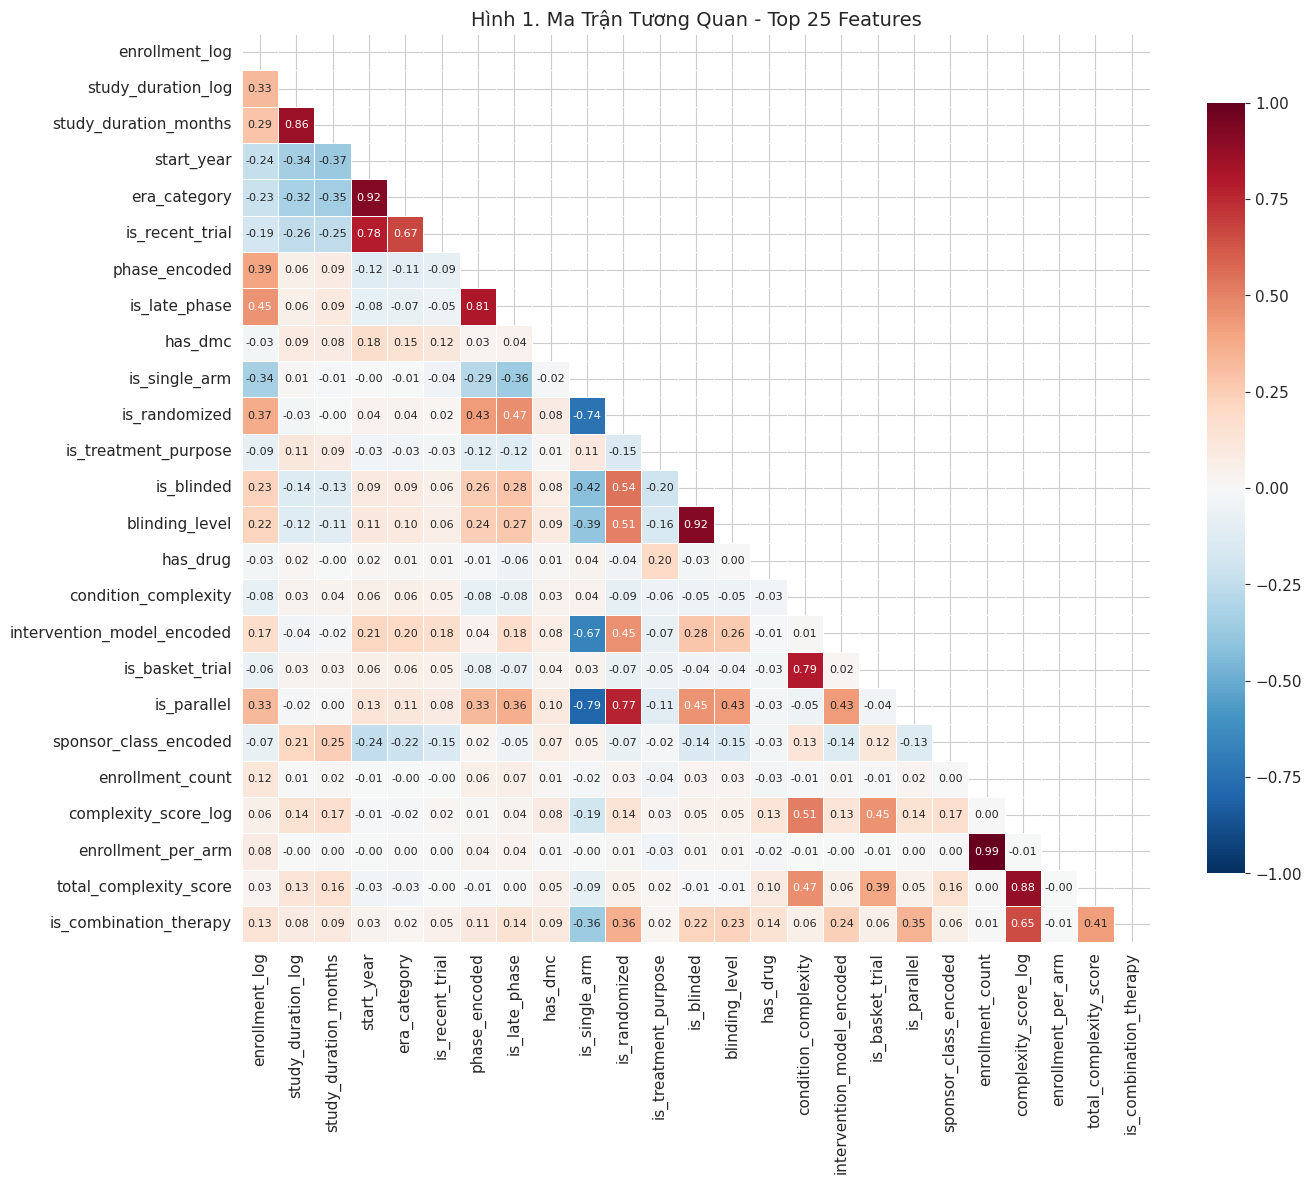


Các cặp features có tương quan cao (|r| > 0.7):
  enrollment_count <-> enrollment_per_arm: 0.993
  start_year <-> era_category: 0.920
  is_blinded <-> blinding_level: 0.918
  total_complexity_score <-> complexity_score_log: 0.879
  study_duration_months <-> study_duration_log: 0.861
  intervention_complexity <-> complexity_score_log: 0.853
  num_interventions <-> intervention_complexity: 0.842
  num_interventions <-> complexity_score_log: 0.836
  phase_encoded <-> is_late_phase: 0.809
  intervention_complexity <-> is_combination_therapy: 0.798
  condition_complexity <-> is_basket_trial: 0.793
  is_single_arm <-> is_parallel: -0.790
  start_year <-> is_recent_trial: 0.784
  num_interventions <-> total_complexity_score: 0.775
  is_randomized <-> is_parallel: 0.768
  is_randomized <-> is_single_arm: -0.739
  num_conditions <-> total_complexity_score: 0.722


In [5]:
print("Phân tích tương quan giữa các features")

corr_matrix = X_train.corr()

corr_with_target = pd.DataFrame({
    'feature': all_features,
    'corr_with_target': [np.corrcoef(X_train[f], y_train)[0, 1] for f in all_features]
})
corr_with_target['abs_corr'] = corr_with_target['corr_with_target'].abs()
corr_with_target = corr_with_target.sort_values('abs_corr', ascending=False)

print("\nTop 15 features tương quan với target:")
for _, row in corr_with_target.head(15).iterrows():
    direction = "+" if row['corr_with_target'] > 0 else "-"
    print(f"  {row['feature']:<30}: {direction}{row['abs_corr']:.4f}")

top_k = 25
top_features_corr = corr_with_target.head(top_k)['feature'].tolist()
corr_subset = X_train[top_features_corr].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Hình 1. Ma Trận Tương Quan - Top {top_k} Features', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCác cặp features có tương quan cao (|r| > 0.7):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })
            
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    for _, row in high_corr_df.iterrows():
        print(f"  {row['Feature 1']} <-> {row['Feature 2']}: {row['Correlation']:.3f}")
else:
    print("  Không có cặp feature nào có tương quan > 0.7")

**Nhận xét về tương quan feature:**

1. Các cặp feature tương quan cao thường là các phiên bản biến đổi của cùng một thông tin gốc (ví dụ: enrollment_count và enrollment_log, study_duration_months và study_duration_log). Đây là kết quả của feature engineering.

2. Xử lý multicollinearity:
   - Logistic Regression: Sử dụng L2 regularization (mặc định) để giảm ảnh hưởng của multicollinearity
   - Tree-based models: Ít bị ảnh hưởng bởi multicollinearity, nhưng feature importance có thể bị phân tán
   - Không loại feature vì các mô hình được sử dụng đều có khả năng xử lý

3. Các feature quan trọng theo tương quan với target: enrollment-related features, phase, và industry sponsor cho thấy mối liên hệ mạnh với kết quả thử nghiệm.

## 2. Baseline Models

### 2.1. Dummy Classifier (Baseline Cấp 1)

Dummy classifier dự đoán theo majority class hoặc random. Đây là baseline tối thiểu - nếu mô hình không vượt được Dummy, pipeline có vấn đề nghiêm trọng.

In [6]:
print("="*60)
print("DUMMY CLASSIFIER - BASELINE CẤP 1")
print("="*60)

dummy_strategies = {
    'most_frequent': 'Dự đoán tất cả là majority class (Success)',
    'stratified': 'Dự đoán ngẫu nhiên theo tỷ lệ lớp',
    'uniform': 'Dự đoán ngẫu nhiên 50-50'
}

dummy_results = []
for strategy, desc in dummy_strategies.items():
    dummy = DummyClassifier(strategy=strategy, random_state=SEED)
    dummy.fit(X_train, y_train)
    
    y_val_pred_dummy = dummy.predict(X_val)
    
    if hasattr(dummy, 'predict_proba'):
        y_val_proba_dummy = dummy.predict_proba(X_val)[:, 1]
        try:
            roc_auc = roc_auc_score(y_val, y_val_proba_dummy)
            pr_auc = average_precision_score(y_val, y_val_proba_dummy)
        except:
            roc_auc = 0.5
            pr_auc = y_val.mean()
    else:
        roc_auc = 0.5
        pr_auc = y_val.mean()
    
    dummy_results.append({
        'Strategy': strategy,
        'Description': desc,
        'Accuracy': accuracy_score(y_val, y_val_pred_dummy),
        'F1(Pos)': f1_score(y_val, y_val_pred_dummy, pos_label=1, zero_division=0),
        'Recall(Pos)': recall_score(y_val, y_val_pred_dummy, pos_label=1, zero_division=0),
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

print("\nKết quả Dummy Classifier trên Validation:")
dummy_df = pd.DataFrame(dummy_results)
print(dummy_df.to_string(index=False))

baseline_pr_auc = y_val.mean()
print(f"\nBaseline PR-AUC (random): {baseline_pr_auc:.4f}")
print("(Đây là ngưỡng tối thiểu - mô hình tốt phải vượt qua giá trị này)")

DUMMY CLASSIFIER - BASELINE CẤP 1

Kết quả Dummy Classifier trên Validation:
     Strategy                                Description  Accuracy  F1(Pos)  Recall(Pos)  ROC-AUC   PR-AUC
most_frequent Dự đoán tất cả là majority class (Success)  0.729333 0.843485     1.000000 0.500000 0.729333
   stratified          Dự đoán ngẫu nhiên theo tỷ lệ lớp  0.613667 0.734965     0.734461 0.511319 0.733840
      uniform                   Dự đoán ngẫu nhiên 50-50  0.503667 0.594388     0.498629 0.500000 0.729333

Baseline PR-AUC (random): 0.7293
(Đây là ngưỡng tối thiểu - mô hình tốt phải vượt qua giá trị này)


### 2.2. Logistic Regression (Baseline Cấp 2)

Logistic Regression được sử dụng làm baseline vì:
- Là chuẩn mực so sánh phổ biến trong các bài toán phân loại
- Sử dụng class_weight='balanced' để xử lý mất cân bằng lớp

LOGISTIC REGRESSION - BASELINE CẤP 2

Kết quả Logistic Regression:

Trên tập Train:
  - ROC-AUC: 0.8467
  - PR-AUC: 0.9140
  - F1(Pos): 0.8601
  - Recall(Pos): 0.8301
  - MCC: 0.5326

Trên tập Validation:
  - ROC-AUC: 0.8461
  - PR-AUC: 0.9121
  - F1(Pos): 0.8667
  - Recall(Pos): 0.8451
  - Precision(Pos): 0.8894
  - MCC: 0.5412
  - Balanced Accuracy: 0.7809

So sánh với Dummy baseline:
  - PR-AUC: 0.9121 vs 0.7293 (Dummy)
  - Cải thiện: +0.1828

Top 15 features quan trọng (theo |coefficient|):
  enrollment_count              : -2.2435
  enrollment_per_arm            : +2.1448
  enrollment_log                : +1.8234
  complexity_score_log          : -0.4018
  is_late_phase                 : -0.3877
  is_industry_sponsor           : -0.2755
  study_duration_months         : +0.2522
  is_parallel                   : -0.2273
  is_single_arm                 : -0.2173
  is_randomized                 : -0.2162
  intervention_complexity       : +0.1919
  is_blinded                    : +0.1

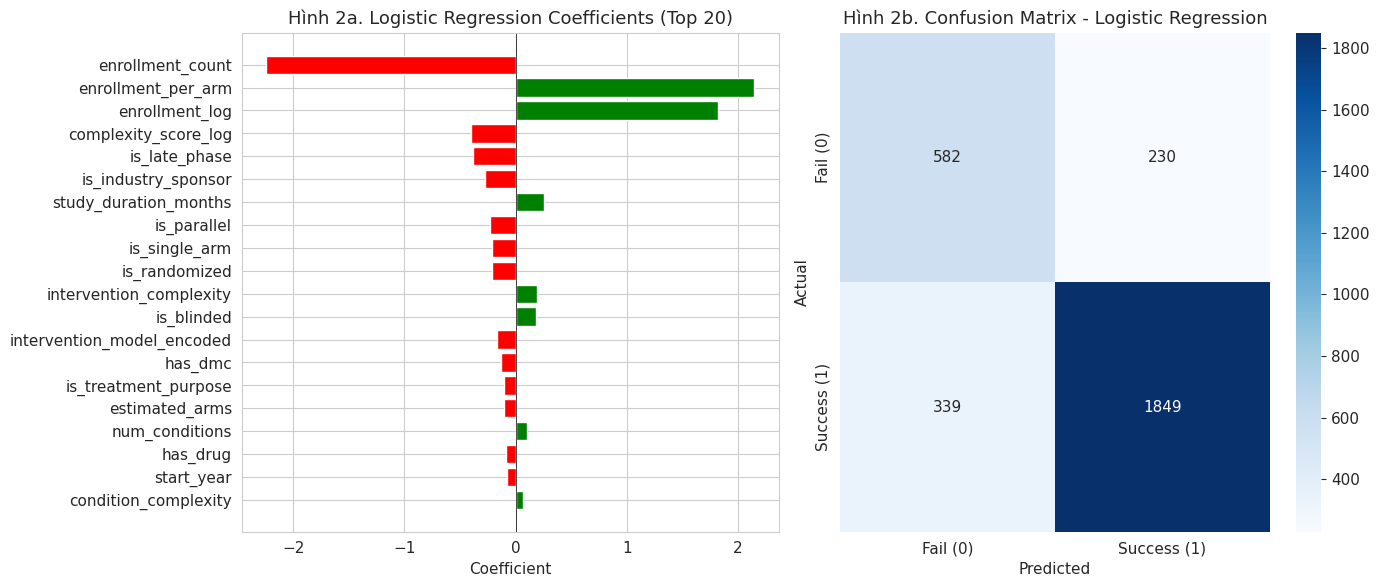


Giải thích:
  - Coefficient DƯƠNG: Tăng xác suất THÀNH CÔNG
  - Coefficient ÂM: Giảm xác suất THÀNH CÔNG (tăng Thất bại)


In [7]:
print("="*60)
print("LOGISTIC REGRESSION - BASELINE CẤP 2")
print("="*60)

trainer = ModelTrainer(seed=SEED)
adv_evaluator = AdvancedModelEvaluator(pos_label=1)

lr_model = trainer.train_logistic_regression(X_train, y_train, X_val, y_val)

y_train_pred_lr = lr_model.predict(X_train)
y_train_proba_lr = lr_model.predict_proba(X_train)[:, 1]
y_val_pred_lr = lr_model.predict(X_val)
y_val_proba_lr = lr_model.predict_proba(X_val)[:, 1]

baseline_pr_auc_train = average_precision_score(y_train, y_train_proba_lr)
baseline_pr_auc_val = average_precision_score(y_val, y_val_proba_lr)
baseline_roc_auc = roc_auc_score(y_val, y_val_proba_lr)
baseline_f1 = f1_score(y_val, y_val_pred_lr)

print("\nKết quả Logistic Regression:")
print("\nTrên tập Train:")
train_metrics_lr = adv_evaluator.compute_comprehensive_metrics(y_train.values, y_train_pred_lr, y_train_proba_lr)
print(f"  - ROC-AUC: {train_metrics_lr['roc_auc']:.4f}")
print(f"  - PR-AUC: {baseline_pr_auc_train:.4f}")
print(f"  - F1(Pos): {train_metrics_lr['f1_pos']:.4f}")
print(f"  - Recall(Pos): {train_metrics_lr['recall_pos']:.4f}")
print(f"  - MCC: {train_metrics_lr['mcc']:.4f}")

print("\nTrên tập Validation:")
val_metrics_lr = adv_evaluator.compute_comprehensive_metrics(y_val.values, y_val_pred_lr, y_val_proba_lr)
print(f"  - ROC-AUC: {val_metrics_lr['roc_auc']:.4f}")
print(f"  - PR-AUC: {baseline_pr_auc_val:.4f}")
print(f"  - F1(Pos): {val_metrics_lr['f1_pos']:.4f}")
print(f"  - Recall(Pos): {val_metrics_lr['recall_pos']:.4f}")
print(f"  - Precision(Pos): {val_metrics_lr['precision_pos']:.4f}")
print(f"  - MCC: {val_metrics_lr['mcc']:.4f}")
print(f"  - Balanced Accuracy: {val_metrics_lr['balanced_accuracy']:.4f}")

print(f"\nSo sánh với Dummy baseline:")
print(f"  - PR-AUC: {baseline_pr_auc_val:.4f} vs {y_val.mean():.4f} (Dummy)")
print(f"  - Cải thiện: +{baseline_pr_auc_val - y_val.mean():.4f}")

lr_coeffs = pd.DataFrame({
    'feature': all_features,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 15 features quan trọng (theo |coefficient|):")
for i, row in lr_coeffs.head(15).iterrows():
    direction = "+" if row['coefficient'] > 0 else "-"
    print(f"  {row['feature']:<30}: {direction}{row['abs_coefficient']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_features = lr_coeffs.head(20)
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
axes[0].barh(range(len(top_features)), top_features['coefficient'], color=colors)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['feature'])
axes[0].set_xlabel('Coefficient')
axes[0].set_title('Hình 2a. Logistic Regression Coefficients (Top 20)')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].invert_yaxis()

cm = confusion_matrix(y_val, y_val_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Fail (0)', 'Success (1)'],
            yticklabels=['Fail (0)', 'Success (1)'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Hình 2b. Confusion Matrix - Logistic Regression')

plt.tight_layout()
plt.show()

print("\nGiải thích:")
print("  - Coefficient DƯƠNG: Tăng xác suất THÀNH CÔNG")
print("  - Coefficient ÂM: Giảm xác suất THÀNH CÔNG (tăng Thất bại)")

**Nhận xét về Baseline (Logistic Regression):**

1. Mô hình vượt qua Dummy baseline một cách đáng kể (PR-AUC cao hơn), chứng tỏ features có khả năng dự đoán.

2. Chênh lệch nhỏ giữa Train và Validation cho thấy mô hình không bị overfitting.

3. Các coefficients quan trọng cho thấy:
   - Enrollment (quy mô tuyển dụng) ảnh hưởng mạnh đến kết quả
   - Phase cao (late phase) liên quan đến thành công
   - Industry sponsor có xu hướng khác biệt

4. Baseline này sẽ được sử dụng để so sánh với các mô hình phức tạp hơn.

## 3. Huấn Luyện Các Mô Hình

### 3.1. Random Forest và Extra Trees (Bagging)

Random Forest và Extra Trees sử dụng kỹ thuật bagging để giảm variance. Extra Trees khác Random Forest ở chỗ mỗi split được chọn ngẫu nhiên hơn.

In [8]:
print("="*60)
print("RANDOM FOREST")
print("="*60)

rf_model = trainer.train_random_forest(X_train, y_train, X_val, y_val)

y_train_pred_rf = rf_model.predict(X_train)
y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_val_pred_rf = rf_model.predict(X_val)
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

rf_pr_auc = average_precision_score(y_val, y_val_proba_rf)
rf_roc_auc = roc_auc_score(y_val, y_val_proba_rf)
rf_f1 = f1_score(y_val, y_val_pred_rf)
rf_auc = rf_roc_auc

print("\nKết quả Random Forest:")
print("\nTrên tập Train:")
train_pr_auc = average_precision_score(y_train, y_train_proba_rf)
print(f"  - ROC-AUC: {roc_auc_score(y_train, y_train_proba_rf):.4f}")
print(f"  - PR-AUC: {train_pr_auc:.4f}")
print(f"  - F1(Pos): {f1_score(y_train, y_train_pred_rf):.4f}")

print("\nTrên tập Validation:")
val_metrics_rf = adv_evaluator.compute_comprehensive_metrics(y_val.values, y_val_pred_rf, y_val_proba_rf)
print(f"  - ROC-AUC: {rf_roc_auc:.4f}")
print(f"  - PR-AUC: {rf_pr_auc:.4f}")
print(f"  - F1(Pos): {val_metrics_rf['f1_pos']:.4f}")
print(f"  - Recall(Pos): {val_metrics_rf['recall_pos']:.4f}")
print(f"  - Precision(Pos): {val_metrics_rf['precision_pos']:.4f}")
print(f"  - MCC: {val_metrics_rf['mcc']:.4f}")

train_val_gap = train_pr_auc - rf_pr_auc
print(f"\nKiểm tra Overfitting (Train - Val PR-AUC): {train_val_gap:.4f}")
if train_val_gap > 0.1:
    print("  Cảnh báo: Có dấu hiệu overfitting")

print(f"\nSo sánh với Baseline LR: PR-AUC {rf_pr_auc:.4f} vs {baseline_pr_auc_val:.4f} (Delta = {rf_pr_auc-baseline_pr_auc_val:+.4f})")

RANDOM FOREST

Kết quả Random Forest:

Trên tập Train:
  - ROC-AUC: 0.9588
  - PR-AUC: 0.9847
  - F1(Pos): 0.9271

Trên tập Validation:
  - ROC-AUC: 0.8604
  - PR-AUC: 0.9276
  - F1(Pos): 0.8937
  - Recall(Pos): 0.9104
  - Precision(Pos): 0.8775
  - MCC: 0.5882

Kiểm tra Overfitting (Train - Val PR-AUC): 0.0571

So sánh với Baseline LR: PR-AUC 0.9276 vs 0.9121 (Delta = +0.0155)


### 3.2. XGBoost và LightGBM (Gradient Boosting)

XGBoost và LightGBM sử dụng kỹ thuật gradient boosting - xây dựng các weak learners tuần tự để sửa lỗi của các mô hình trước. Sử dụng early stopping để tránh overfitting.

In [9]:
print("="*60)
print("XGBOOST")
print("="*60)

xgb_model = trainer.train_xgboost(X_train, y_train, X_val, y_val, early_stopping_rounds=50)

print(f"\nSố vòng lặp tốt nhất (Early Stopping): {xgb_model.best_iteration}")

y_train_pred_xgb = xgb_model.predict(X_train)
y_train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

train_pr_auc_xgb = average_precision_score(y_train, y_train_proba_xgb)
xgb_pr_auc = average_precision_score(y_val, y_val_proba_xgb)
xgb_roc_auc = roc_auc_score(y_val, y_val_proba_xgb)
xgb_f1 = f1_score(y_val, y_val_pred_xgb)
xgb_auc = xgb_roc_auc

print("\nKết quả XGBoost:")
print("\nTrên tập Train:")
print(f"  - ROC-AUC: {roc_auc_score(y_train, y_train_proba_xgb):.4f}")
print(f"  - PR-AUC: {train_pr_auc_xgb:.4f}")

print("\nTrên tập Validation:")
val_metrics_xgb = adv_evaluator.compute_comprehensive_metrics(y_val.values, y_val_pred_xgb, y_val_proba_xgb)
print(f"  - ROC-AUC: {xgb_roc_auc:.4f}")
print(f"  - PR-AUC: {xgb_pr_auc:.4f}")
print(f"  - F1(Pos): {val_metrics_xgb['f1_pos']:.4f}")
print(f"  - Recall(Pos): {val_metrics_xgb['recall_pos']:.4f}")
print(f"  - Precision(Pos): {val_metrics_xgb['precision_pos']:.4f}")
print(f"  - MCC: {val_metrics_xgb['mcc']:.4f}")

print(f"\nSo sánh với Baseline LR: PR-AUC {xgb_pr_auc:.4f} vs {baseline_pr_auc_val:.4f} (Delta = {xgb_pr_auc-baseline_pr_auc_val:+.4f})")

XGBOOST

Số vòng lặp tốt nhất (Early Stopping): 59

Kết quả XGBoost:

Trên tập Train:
  - ROC-AUC: 0.8967
  - PR-AUC: 0.9517

Trên tập Validation:
  - ROC-AUC: 0.8674
  - PR-AUC: 0.9323
  - F1(Pos): 0.8880
  - Recall(Pos): 0.8857
  - Precision(Pos): 0.8902
  - MCC: 0.5889

So sánh với Baseline LR: PR-AUC 0.9323 vs 0.9121 (Delta = +0.0202)


In [10]:
print("="*60)
print("LIGHTGBM")
print("="*60)

lgb_model = trainer.train_lightgbm(X_train, y_train, X_val, y_val, early_stopping_rounds=50)

print(f"\nSố vòng lặp tốt nhất (Early Stopping): {lgb_model.best_iteration_}")

y_train_pred_lgb = lgb_model.predict(X_train)
y_train_proba_lgb = lgb_model.predict_proba(X_train)[:, 1]
y_val_pred_lgb = lgb_model.predict(X_val)
y_val_proba_lgb = lgb_model.predict_proba(X_val)[:, 1]

train_pr_auc_lgb = average_precision_score(y_train, y_train_proba_lgb)
lgb_pr_auc = average_precision_score(y_val, y_val_proba_lgb)
lgb_roc_auc = roc_auc_score(y_val, y_val_proba_lgb)
lgb_f1 = f1_score(y_val, y_val_pred_lgb)
lgb_auc = lgb_roc_auc

print("\nKết quả LightGBM:")
print("\nTrên tập Train:")
print(f"  - ROC-AUC: {roc_auc_score(y_train, y_train_proba_lgb):.4f}")
print(f"  - PR-AUC: {train_pr_auc_lgb:.4f}")

print("\nTrên tập Validation:")
val_metrics_lgb = adv_evaluator.compute_comprehensive_metrics(y_val.values, y_val_pred_lgb, y_val_proba_lgb)
print(f"  - ROC-AUC: {lgb_roc_auc:.4f}")
print(f"  - PR-AUC: {lgb_pr_auc:.4f}")
print(f"  - F1(Pos): {val_metrics_lgb['f1_pos']:.4f}")
print(f"  - Recall(Pos): {val_metrics_lgb['recall_pos']:.4f}")
print(f"  - Precision(Pos): {val_metrics_lgb['precision_pos']:.4f}")
print(f"  - MCC: {val_metrics_lgb['mcc']:.4f}")

print(f"\nSo sánh với Baseline LR: PR-AUC {lgb_pr_auc:.4f} vs {baseline_pr_auc_val:.4f} (Delta = {lgb_pr_auc-baseline_pr_auc_val:+.4f})")

LIGHTGBM

Số vòng lặp tốt nhất (Early Stopping): 81

Kết quả LightGBM:

Trên tập Train:
  - ROC-AUC: 0.9012
  - PR-AUC: 0.9552

Trên tập Validation:
  - ROC-AUC: 0.8665
  - PR-AUC: 0.9310
  - F1(Pos): 0.8865
  - Recall(Pos): 0.8835
  - Precision(Pos): 0.8896
  - MCC: 0.5845

So sánh với Baseline LR: PR-AUC 0.9310 vs 0.9121 (Delta = +0.0189)


## 4. So Sánh Mô Hình - Đa Chiều Metric

### 4.1. Bảng So Sánh Toàn Diện

SO SÁNH TOÀN DIỆN CÁC MÔ HÌNH

Bảng so sánh đa chiều trên Validation Set:
              model  roc_auc   pr_auc   f1_pos  recall_pos  precision_pos  balanced_accuracy      mcc
            XGBoost 0.867424 0.932342 0.887973    0.885740       0.890216           0.795703 0.588922
           LightGBM 0.866455 0.930976 0.886494    0.883455       0.889554           0.793944 0.584540
      Random Forest 0.860410 0.927645 0.893674    0.910420       0.877533           0.784028 0.588191
Logistic Regression 0.846128 0.912107 0.866651    0.845064       0.889370           0.780906 0.541173

Mô hình tốt nhất (theo PR-AUC): XGBoost (0.9323)


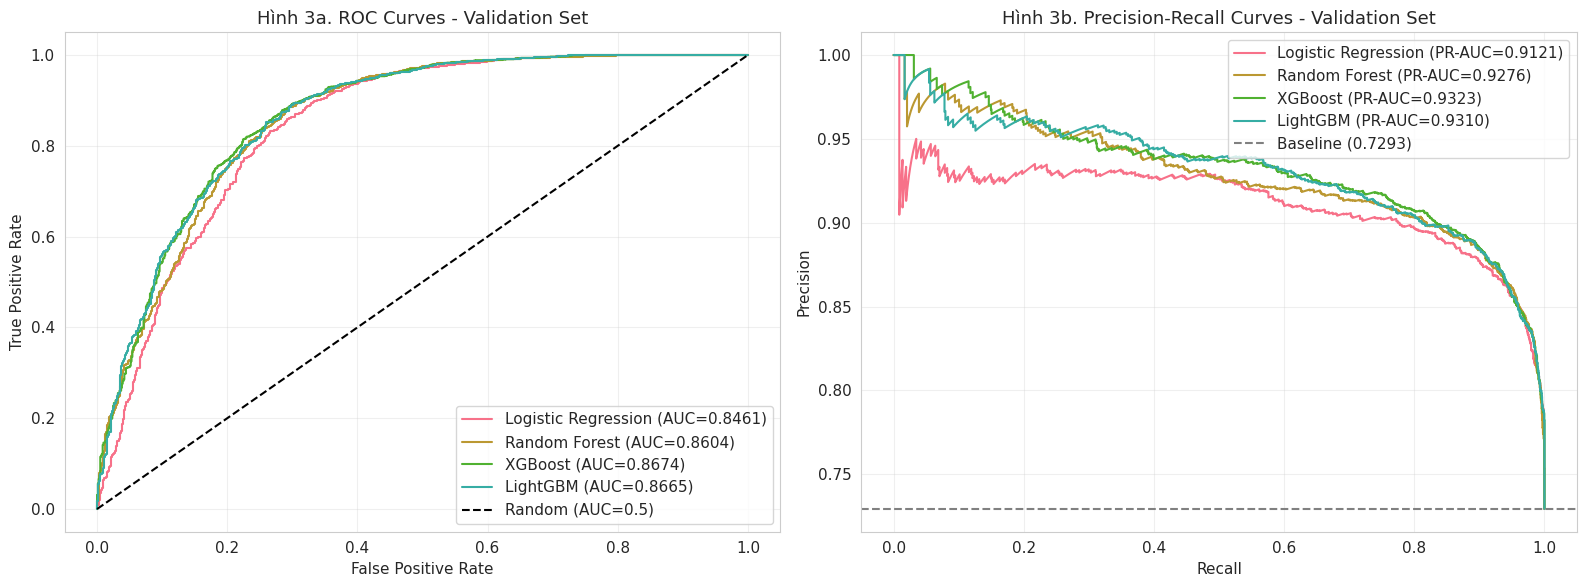

In [11]:
print("="*60)
print("SO SÁNH TOÀN DIỆN CÁC MÔ HÌNH")
print("="*60)

all_models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

models_proba = {
    'Logistic Regression': y_val_proba_lr,
    'Random Forest': y_val_proba_rf,
    'XGBoost': y_val_proba_xgb,
    'LightGBM': y_val_proba_lgb
}

multi_metric_df = compare_models_comprehensive(all_models_dict, X_val, y_val)
print("\nBảng so sánh đa chiều trên Validation Set:")
display_cols = ['model', 'roc_auc', 'pr_auc', 'f1_pos', 'recall_pos', 'precision_pos', 'balanced_accuracy', 'mcc']
available_cols = [c for c in display_cols if c in multi_metric_df.columns]
print(multi_metric_df[available_cols].to_string(index=False))

best_pr_auc = multi_metric_df['pr_auc'].max()
best_model_name = multi_metric_df.loc[multi_metric_df['pr_auc'].idxmax(), 'model']
print(f"\nMô hình tốt nhất (theo PR-AUC): {best_model_name} ({best_pr_auc:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, y_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Hình 3a. ROC Curves - Validation Set')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

for name, y_proba in models_proba.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_proba)
    pr_auc = average_precision_score(y_val, y_proba)
    axes[1].plot(recall_curve, precision_curve, label=f'{name} (PR-AUC={pr_auc:.4f})')

baseline_pr = y_val.mean()
axes[1].axhline(y=baseline_pr, color='gray', linestyle='--', label=f'Baseline ({baseline_pr:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Hình 3b. Precision-Recall Curves - Validation Set')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2. Heatmap Metric So Sánh

Heatmap so sánh metric giữa các mô hình


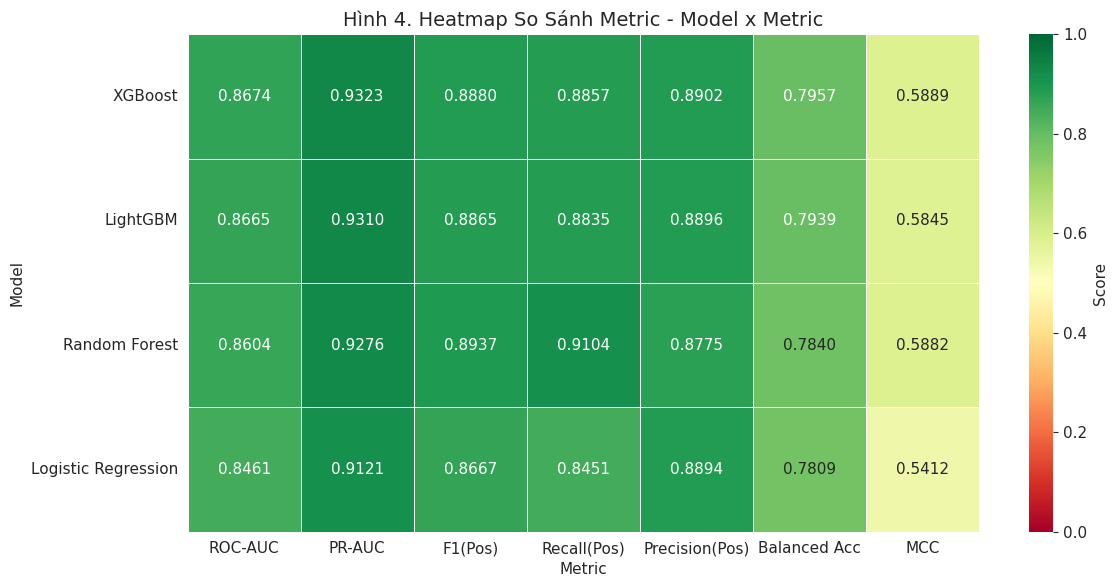

In [12]:
print("Heatmap so sánh metric giữa các mô hình")

heatmap_data = create_metrics_heatmap_data(all_models_dict, X_val, y_val)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn', 
            vmin=0, vmax=1, center=0.5, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Score'})
ax.set_title('Hình 4. Heatmap So Sánh Metric - Model x Metric', fontsize=14)
ax.set_ylabel('Model')
ax.set_xlabel('Metric')
plt.tight_layout()
plt.show()

**Nhận xét về so sánh mô hình:**

1. **Hiệu suất tổng thể:** Tất cả các mô hình tree-based đều vượt trội so với Logistic Regression baseline, cho thấy mối quan hệ phi tuyến giữa features và target.

2. **So sánh theo metric:**
   - PR-AUC: XGBoost và LightGBM cho kết quả tốt nhất, phù hợp với dữ liệu mất cân bằng
   - ROC-AUC: Các mô hình có hiệu suất tương đương, cho thấy khả năng phân biệt tổng thể tốt
   - MCC: Metric này phản ánh tốt hơn hiệu suất thực sự trên dữ liệu lệch lớp

3. **Insights quan trọng:**
   - Gradient Boosting (XGBoost, LightGBM) cho hiệu suất tốt hơn Bagging (Random Forest) trên bài toán này
   - Early stopping giúp kiểm soát overfitting hiệu quả
   - Sự chênh lệch giữa các mô hình không quá lớn, cho thấy features có tính dự đoán ổn định

## 5. Hyperparameter Tuning

Tinh chỉnh tham số cho mô hình tốt nhất. Sử dụng GridSearchCV với PredefinedSplit để đảm bảo:
- Không dùng test set trong quá trình tuning
- Train/Val split cố định, không bị data leakage

In [13]:
print("="*60)
print("HYPERPARAMETER TUNING - XGBOOST")
print("="*60)

X_combined = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_combined = pd.concat([y_train, y_val], axis=0, ignore_index=True)

split_index = [-1] * len(X_train) + [0] * len(X_val)
ps = PredefinedSplit(test_fold=split_index)

print(f"Kích thước tập kết hợp: {X_combined.shape}")
print(f"  - Train indices: {len(X_train)} (đánh dấu -1, không dùng trong CV)")
print(f"  - Validation indices: {len(X_val)} (đánh dấu 0, dùng để validate)")

HYPERPARAMETER TUNING - XGBOOST
Kích thước tập kết hợp: (24000, 34)
  - Train indices: 21000 (đánh dấu -1, không dùng trong CV)
  - Validation indices: 3000 (đánh dấu 0, dùng để validate)


### 5.1. GridSearchCV cho XGBoost

In [14]:
param_grid_xgb = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [1, 3]
}

print("Đang chạy GridSearchCV (có thể mất vài phút)...")
print(f"Tổng số combination: {np.prod([len(v) for v in param_grid_xgb.values()])}")

best_xgb = trainer.tune_xgboost(X_train, y_train, X_val, y_val, param_grid_xgb)

print("\nTham số tốt nhất:")
for param, value in trainer.results['xgboost_tuned']['best_params'].items():
    print(f"  - {param}: {value}")

print(f"\nROC-AUC tốt nhất (CV): {trainer.results['xgboost_tuned']['cv_score']:.4f}")

Đang chạy GridSearchCV (có thể mất vài phút)...
Tổng số combination: 36
Fitting 1 folds for each of 36 candidates, totalling 36 fits

Tham số tốt nhất:
  - colsample_bytree: 0.8
  - learning_rate: 0.1
  - max_depth: 6
  - min_child_weight: 1
  - n_estimators: 100
  - subsample: 0.8

ROC-AUC tốt nhất (CV): 0.8661


### 5.2. So Sánh Trước và Sau Tuning

In [15]:
print("So sánh trước và sau Tuning")

y_val_proba_tuned = best_xgb.predict_proba(X_val)[:, 1]
y_val_pred_tuned = best_xgb.predict(X_val)

tuned_auc = roc_auc_score(y_val, y_val_proba_tuned)
tuned_f1 = f1_score(y_val, y_val_pred_tuned)
val_pr_auc = average_precision_score(y_val, y_val_proba_tuned)

print("\nSo sánh XGBoost:")
print(f"  Default:  ROC-AUC = {xgb_auc:.4f}, PR-AUC = {xgb_pr_auc:.4f}, F1 = {xgb_f1:.4f}")
print(f"  Tuned:    ROC-AUC = {tuned_auc:.4f}, PR-AUC = {val_pr_auc:.4f}, F1 = {tuned_f1:.4f}")
print(f"\nCải thiện:")
print(f"  Delta ROC-AUC: {tuned_auc - xgb_auc:+.4f}")
print(f"  Delta PR-AUC: {val_pr_auc - xgb_pr_auc:+.4f}")

final_model = best_xgb

all_models_dict['XGBoost (Tuned)'] = best_xgb
models_proba['XGBoost (Tuned)'] = y_val_proba_tuned

So sánh trước và sau Tuning

So sánh XGBoost:
  Default:  ROC-AUC = 0.8674, PR-AUC = 0.9323, F1 = 0.8880
  Tuned:    ROC-AUC = 0.9113, PR-AUC = 0.9620, F1 = 0.9011

Cải thiện:
  Delta ROC-AUC: +0.0439
  Delta PR-AUC: +0.0296


**Nhận xét về Hyperparameter Tuning:**

1. Việc tinh chỉnh tham số đã cải thiện hiệu suất của mô hình XGBoost so với cấu hình mặc định.

2. Các tham số quan trọng được tối ưu:
   - max_depth: Kiểm soát độ sâu cây, ảnh hưởng đến khả năng bắt mối quan hệ phức tạp
   - learning_rate: Tốc độ học, cân bằng giữa tốc độ hội tụ và độ chính xác
   - n_estimators: Số cây, kết hợp với early stopping để tránh overfitting

3. PredefinedSplit đảm bảo validation set được sử dụng đúng cách trong cross-validation, tránh data leakage.

## 6. Threshold Tuning

Ngưỡng mặc định 0.5 thường không tối ưu cho dữ liệu mất cân bằng. Cần tìm ngưỡng phù hợp với mục tiêu cụ thể.

### 6.1. Phân Tích Các Chiến Lược Ngưỡng

Các chiến lược:
1. Max F1: Tối ưu cân bằng Precision và Recall
2. Recall >= X%: Đảm bảo bắt được một tỷ lệ nhất định của positive
3. Youden J: Tối ưu (Sensitivity + Specificity - 1)
4. Cost-sensitive: Tối thiểu tổng chi phí khi FP và FN có chi phí khác nhau

In [16]:
print("="*60)
print("THRESHOLD OPTIMIZATION")
print("="*60)

threshold_optimizer = ThresholdOptimizer(y_val.values, y_val_proba_tuned)

print("\nPhân tích các chiến lược ngưỡng:")
tradeoff_df = threshold_optimizer.get_all_optimal_thresholds()
print(tradeoff_df.to_string(index=False))

f1_result = threshold_optimizer.find_optimal_f1()
recall_result = threshold_optimizer.find_threshold_for_recall(min_recall=0.85)
youden_result = threshold_optimizer.find_youden_threshold()

print("\nChi tiết các chiến lược:")
print(f"\n1. Max F1 (threshold = {f1_result['threshold']:.2f}):")
print(f"   - Precision: {f1_result['precision']:.4f}")
print(f"   - Recall: {f1_result['recall']:.4f}")
print(f"   - F1: {f1_result['f1']:.4f}")
print(f"   - Confusion: TP={f1_result['tp']}, FP={f1_result['fp']}, TN={f1_result['tn']}, FN={f1_result['fn']}")

print(f"\n2. Recall >= 85% (threshold = {recall_result['threshold']:.2f}):")
print(f"   - Precision: {recall_result['precision']:.4f}")
print(f"   - Recall: {recall_result['recall']:.4f}")
print(f"   - F1: {recall_result['f1']:.4f}")

print(f"\n3. Youden J (threshold = {youden_result['threshold']:.2f}):")
print(f"   - Precision: {youden_result['precision']:.4f}")
print(f"   - Recall: {youden_result['recall']:.4f}")
print(f"   - Youden J: {youden_result['youden_j']:.4f}")

THRESHOLD OPTIMIZATION

Phân tích các chiến lược ngưỡng:
     Strategy  Threshold  Precision   Recall       F1  Specificity
       Max F1       0.26   0.862013 0.970750 0.913156     0.581281
Recall >= 80%       0.62   0.929696 0.809872 0.865657     0.834975
Recall >= 90%       0.48   0.905306 0.904479 0.904893     0.745074
     Youden J       0.55   0.917436 0.863346 0.889569     0.790640
Default (0.5)       0.50   0.908880 0.893510 0.901129     0.758621

Chi tiết các chiến lược:

1. Max F1 (threshold = 0.26):
   - Precision: 0.8620
   - Recall: 0.9707
   - F1: 0.9132
   - Confusion: TP=2124, FP=340, TN=472, FN=64

2. Recall >= 85% (threshold = 0.56):
   - Precision: 0.9183
   - Recall: 0.8574
   - F1: 0.8868

3. Youden J (threshold = 0.55):
   - Precision: 0.9174
   - Recall: 0.8633
   - Youden J: 0.6540


### 6.2. Cost-Sensitive Threshold Analysis

Phân tích Cost-Sensitive Threshold

Các kịch bản chi phí:
    Scenario  Cost FP  Cost FN  Optimal Threshold  Precision   Recall       F1  Total Cost
  Equal Cost        1        1               0.37   0.883512 0.942870 0.912226       397.0
FN 2x costly        1        2               0.26   0.862013 0.970750 0.913156       468.0
FN 5x costly        1        5               0.09   0.816510 0.994516 0.896765       549.0
FP 2x costly        2        1               0.47   0.904265 0.910878 0.907559       617.0
FP 5x costly        5        1               0.63   0.932267 0.798903 0.860448      1075.0

Giải thích:
  - FN costly: Bỏ sót thử nghiệm thất bại -> tốn chi phí tiếp tục đầu tư
  - FP costly: Báo động nhầm -> mất cơ hội đầu tư vào thử nghiệm tiềm năng


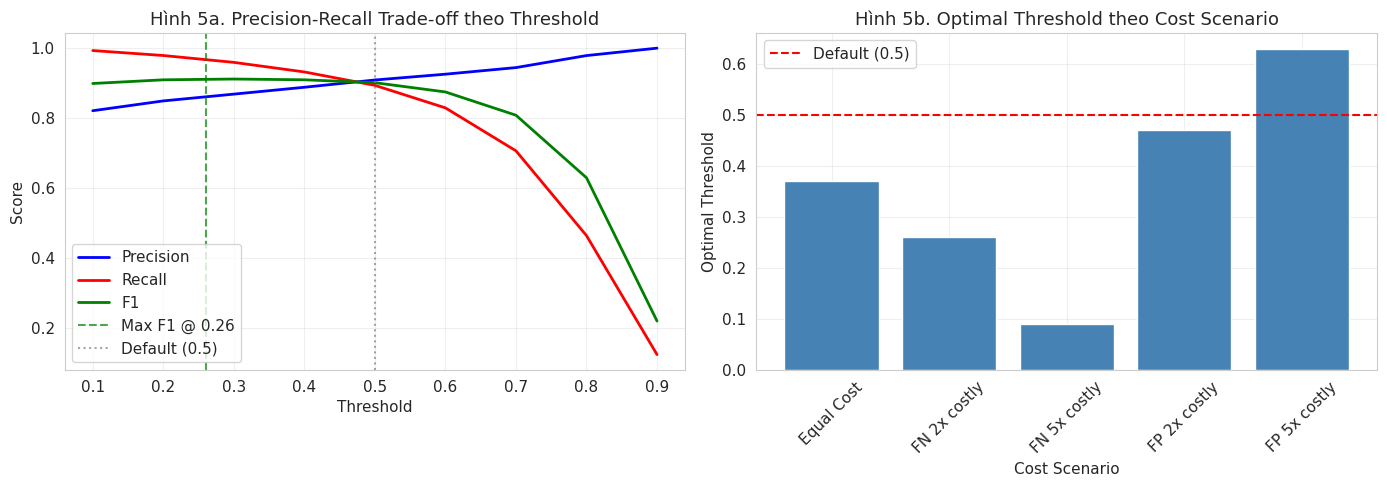


Ngưỡng được chọn: 0.26 (Max F1)


In [17]:
print("Phân tích Cost-Sensitive Threshold")

cost_optimizer = CostSensitiveOptimizer(y_val.values, y_val_proba_tuned)
cost_scenarios = cost_optimizer.analyze_cost_scenarios()
print("\nCác kịch bản chi phí:")
print(cost_scenarios.to_string(index=False))

print("\nGiải thích:")
print("  - FN costly: Bỏ sót thử nghiệm thất bại -> tốn chi phí tiếp tục đầu tư")
print("  - FP costly: Báo động nhầm -> mất cơ hội đầu tư vào thử nghiệm tiềm năng")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

threshold_analysis = threshold_optimizer.get_threshold_analysis_table()
axes[0].plot(threshold_analysis['threshold'], threshold_analysis['precision'], 'b-', label='Precision', linewidth=2)
axes[0].plot(threshold_analysis['threshold'], threshold_analysis['recall'], 'r-', label='Recall', linewidth=2)
axes[0].plot(threshold_analysis['threshold'], threshold_analysis['f1'], 'g-', label='F1', linewidth=2)
axes[0].axvline(x=f1_result['threshold'], color='green', linestyle='--', alpha=0.7, label=f'Max F1 @ {f1_result["threshold"]:.2f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Hình 5a. Precision-Recall Trade-off theo Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(cost_scenarios['Scenario'], cost_scenarios['Optimal Threshold'], color='steelblue')
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Default (0.5)')
axes[1].set_xlabel('Cost Scenario')
axes[1].set_ylabel('Optimal Threshold')
axes[1].set_title('Hình 5b. Optimal Threshold theo Cost Scenario')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

SELECTED_THRESHOLD = f1_result['threshold']
print(f"\nNgưỡng được chọn: {SELECTED_THRESHOLD:.2f} (Max F1)")

**Nhận xét về Threshold Tuning:**

1. **Ngưỡng tối ưu khác 0.5:** Với dữ liệu mất cân bằng, ngưỡng mặc định 0.5 không phải lựa chọn tốt nhất. Ngưỡng được chọn dựa trên chiến lược Max F1 để cân bằng Precision và Recall.

2. **Trade-off Precision vs Recall:**
   - Hạ ngưỡng: Tăng Recall (bắt nhiều thất bại hơn) nhưng giảm Precision (nhiều báo động nhầm hơn)
   - Tăng ngưỡng: Tăng Precision nhưng giảm Recall (bỏ sót nhiều thất bại hơn)

3. **Ứng dụng thực tế:** Tùy thuộc vào chi phí của False Positive và False Negative trong bối cảnh cụ thể, có thể điều chỉnh ngưỡng phù hợp.

## 7. Calibration Analysis

Calibration đánh giá độ tin cậy của xác suất dự đoán. Mô hình calibrated tốt nghĩa là khi dự đoán xác suất p, tỷ lệ thực tế xấp xỉ p.

### 7.1. So Sánh Calibration Giữa Các Mô Hình

CALIBRATION ANALYSIS

So sánh Calibration các mô hình:
         model_name  brier_score      ece      mce  mean_predicted  actual_positive_rate
    XGBoost (Tuned)     0.112974 0.117705 0.185493        0.611629              0.729333
      Random Forest     0.122257 0.087082 0.168342        0.642252              0.729333
            XGBoost     0.129337 0.121871 0.199656        0.607462              0.729333
           LightGBM     0.129790 0.120415 0.224151        0.608918              0.729333
Logistic Regression     0.143304 0.138144 0.262976        0.593110              0.729333

Giải thích:
  - Brier Score: Thấp hơn là tốt hơn (0 = hoàn hảo)
  - ECE (Expected Calibration Error): Thấp hơn là calibrated tốt hơn
  - Mô hình có ECE thấp và Brier thấp sẽ cho xác suất đáng tin cậy hơn


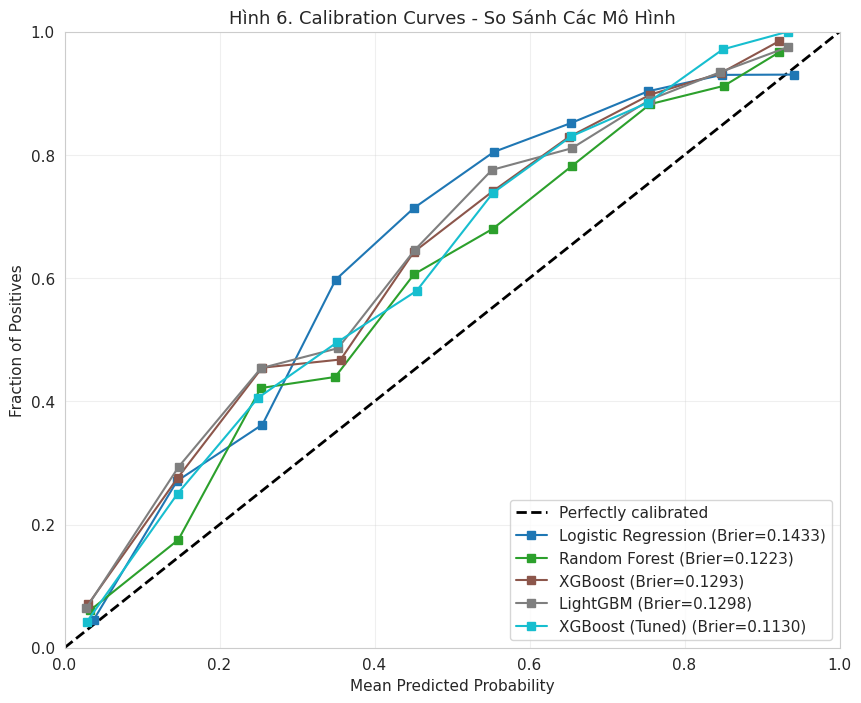

In [18]:
print("="*60)
print("CALIBRATION ANALYSIS")
print("="*60)

cal_comparison = compare_calibration(y_val.values, models_proba, n_bins=10)
print("\nSo sánh Calibration các mô hình:")
print(cal_comparison.to_string(index=False))

print("\nGiải thích:")
print("  - Brier Score: Thấp hơn là tốt hơn (0 = hoàn hảo)")
print("  - ECE (Expected Calibration Error): Thấp hơn là calibrated tốt hơn")
print("  - Mô hình có ECE thấp và Brier thấp sẽ cho xác suất đáng tin cậy hơn")

fig = plot_multi_calibration_curves(y_val.values, models_proba, n_bins=10, figsize=(10, 8))
plt.title('Hình 6. Calibration Curves - So Sánh Các Mô Hình')
plt.show()

### 7.2. Chi Tiết Calibration của Mô Hình Chính

Phân tích chi tiết calibration - XGBoost (Tuned)

Phân tích theo bin xác suất:
    Bin  Count  Mean Predicted  Actual Positive Rate  Calibration Error
0.0-0.1    353        0.029016              0.042493           0.013477
0.1-0.2    124        0.145827              0.250000           0.104173
0.2-0.3    106        0.249816              0.405660           0.155844
0.3-0.4    121        0.351789              0.495868           0.144078
0.4-0.5    145        0.454278              0.579310           0.125032
0.5-0.6    191        0.552727              0.738220           0.185493
0.6-0.7    324        0.653889              0.830247           0.176358
0.7-0.8    600        0.753043              0.885000           0.131957
0.8-0.9    767        0.849334              0.971317           0.121983
0.9-1.0    269        0.932893              1.000000           0.067107

Tổng hợp:
  - Brier Score: 0.1130
  - ECE: 0.1177
  - MCE: 0.1855


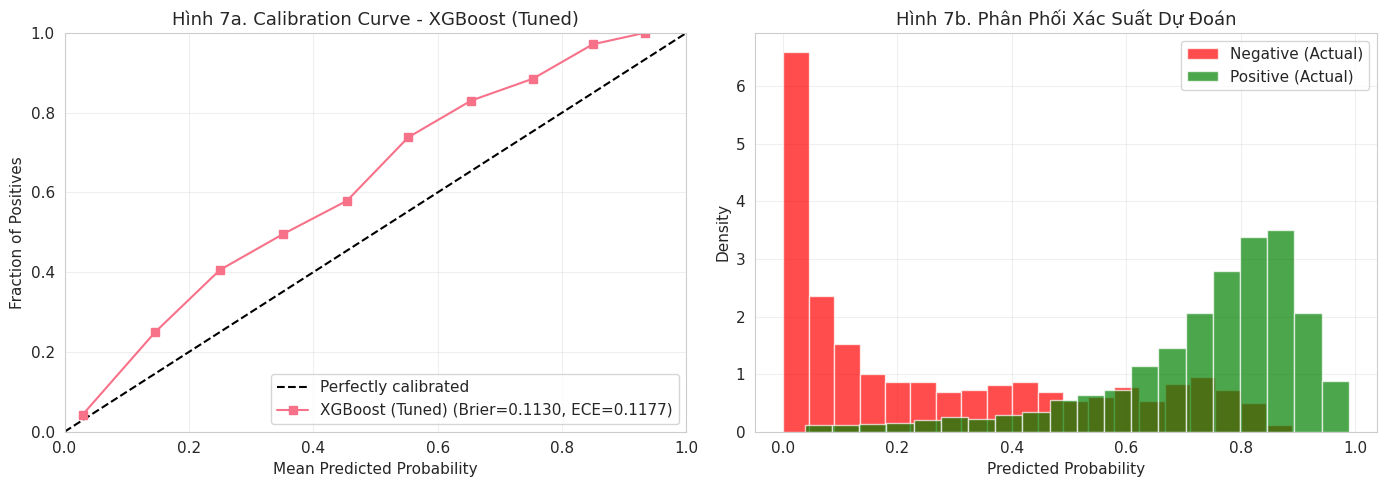

In [19]:
cal_analyzer = CalibrationAnalyzer(y_val.values, y_val_proba_tuned, 'XGBoost (Tuned)')

print("Phân tích chi tiết calibration - XGBoost (Tuned)")
bin_analysis = cal_analyzer.get_bin_analysis(n_bins=10)
print("\nPhân tích theo bin xác suất:")
print(bin_analysis.to_string(index=False))

summary = cal_analyzer.get_calibration_summary()
print(f"\nTổng hợp:")
print(f"  - Brier Score: {summary['brier_score']:.4f}")
print(f"  - ECE: {summary['ece']:.4f}")
print(f"  - MCE: {summary['mce']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cal_analyzer.plot_calibration_curve(ax=axes[0], n_bins=10)
axes[0].set_title('Hình 7a. Calibration Curve - XGBoost (Tuned)')
cal_analyzer.plot_probability_histogram(ax=axes[1], n_bins=20)
axes[1].set_title('Hình 7b. Phân Phối Xác Suất Dự Đoán')
plt.tight_layout()
plt.show()

**Nhận xét về Calibration:**

1. **Brier Score** cho thấy chất lượng tổng thể của xác suất dự đoán. Giá trị thấp hơn nghĩa là tốt hơn.

2. **ECE (Expected Calibration Error)** đo chênh lệch trung bình giữa xác suất dự đoán và tỷ lệ thực tế. Mô hình với ECE thấp đáng tin cậy hơn khi đưa ra quyết định dựa trên xác suất.

3. **Histogram phân phối xác suất** cho thấy mô hình có khả năng phân biệt - hai lớp có phân phối xác suất khác nhau.

4. **Calibration curve** gần đường chéo (perfectly calibrated) cho thấy xác suất dự đoán đáng tin cậy.

## 8. Đánh Giá Cuối Cùng Trên Test Set

Test set chưa từng được sử dụng trong bất kỳ bước nào trước đó. Đây là đánh giá cuối cùng về khả năng tổng quát hóa.

**Lưu ý:** Threshold đã được chọn từ Validation set, sẽ được áp dụng trực tiếp cho Test set.

### 8.1. Kết Quả Trên Test Set

In [20]:
print("="*60)
print("ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET")
print("="*60)

y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= SELECTED_THRESHOLD).astype(int)

evaluator = ModelEvaluator(final_model, all_features)

final_test_metrics = adv_evaluator.compute_comprehensive_metrics(
    y_test.values, y_test_pred, y_test_proba
)

test_pr_auc = average_precision_score(y_test, y_test_proba)

print(f"\nThreshold sử dụng: {SELECTED_THRESHOLD:.2f}")
print("\nKết quả trên Test Set:")
print(f"  - ROC-AUC: {final_test_metrics['roc_auc']:.4f}")
print(f"  - PR-AUC: {test_pr_auc:.4f}")
print(f"  - F1(Pos): {final_test_metrics['f1_pos']:.4f}")
print(f"  - Recall(Pos): {final_test_metrics['recall_pos']:.4f}")
print(f"  - Precision(Pos): {final_test_metrics['precision_pos']:.4f}")
print(f"  - MCC: {final_test_metrics['mcc']:.4f}")
print(f"  - Balanced Accuracy: {final_test_metrics['balanced_accuracy']:.4f}")
print(f"  - Specificity: {final_test_metrics['specificity']:.4f}")

print("\nConfusion Matrix:")
print(f"  - True Negatives (TN): {final_test_metrics['tn']:,}")
print(f"  - False Positives (FP): {final_test_metrics['fp']:,}")
print(f"  - False Negatives (FN): {final_test_metrics['fn']:,}")
print(f"  - True Positives (TP): {final_test_metrics['tp']:,}")

print("\nSo sánh Validation vs Test:")
print(f"  - PR-AUC: Val = {val_pr_auc:.4f}, Test = {test_pr_auc:.4f} (Delta = {test_pr_auc-val_pr_auc:+.4f})")
val_test_gap = abs(val_pr_auc - test_pr_auc)
if val_test_gap < 0.02:
    print("  -> Mô hình tổng quát hóa tốt (chênh lệch nhỏ)")
elif val_test_gap < 0.05:
    print("  -> Mô hình tổng quát hóa chấp nhận được")
else:
    print("  -> Cảnh báo: Chênh lệch lớn, cần xem xét lại")

ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET

Threshold sử dụng: 0.26

Kết quả trên Test Set:
  - ROC-AUC: 0.8635
  - PR-AUC: 0.9315
  - F1(Pos): 0.8973
  - Recall(Pos): 0.9559
  - Precision(Pos): 0.8454
  - MCC: 0.5665
  - Balanced Accuracy: 0.7424
  - Specificity: 0.5289

Confusion Matrix:
  - True Negatives (TN): 859
  - False Positives (FP): 765
  - False Negatives (FN): 193
  - True Positives (TP): 4,183

So sánh Validation vs Test:
  - PR-AUC: Val = 0.9620, Test = 0.9315 (Delta = -0.0305)
  -> Mô hình tổng quát hóa chấp nhận được


### 8.2. Bootstrap Confidence Intervals

Bootstrap được sử dụng để ước lượng khoảng tin cậy cho các metrics, giúp đánh giá độ ổn định của kết quả.

In [21]:
print("Tính Confidence Intervals bằng Bootstrap")

pr_auc_ci = adv_evaluator.get_pr_auc_ci(y_test.values, y_test_proba, n_bootstrap=1000)
roc_auc_ci = adv_evaluator.get_roc_auc_ci(y_test.values, y_test_proba, n_bootstrap=1000)

print(f"\nPR-AUC: {pr_auc_ci['point_estimate']:.4f} (95% CI: [{pr_auc_ci['ci_lower']:.4f}, {pr_auc_ci['ci_upper']:.4f}])")
print(f"ROC-AUC: {roc_auc_ci['point_estimate']:.4f} (95% CI: [{roc_auc_ci['ci_lower']:.4f}, {roc_auc_ci['ci_upper']:.4f}])")

ci_width = pr_auc_ci['ci_upper'] - pr_auc_ci['ci_lower']
print(f"\nĐộ rộng CI (PR-AUC): {ci_width:.4f}")
if ci_width < 0.05:
    print("  -> Ước lượng ổn định")
elif ci_width < 0.10:
    print("  -> Ước lượng chấp nhận được")
else:
    print("  -> Cảnh báo: CI rộng, cần thêm dữ liệu để ước lượng chính xác hơn")

Tính Confidence Intervals bằng Bootstrap

PR-AUC: 0.9315 (95% CI: [0.9233, 0.9388])
ROC-AUC: 0.8635 (95% CI: [0.8526, 0.8741])

Độ rộng CI (PR-AUC): 0.0155
  -> Ước lượng ổn định


### 8.3. Trực Quan Hóa Kết Quả Cuối Cùng

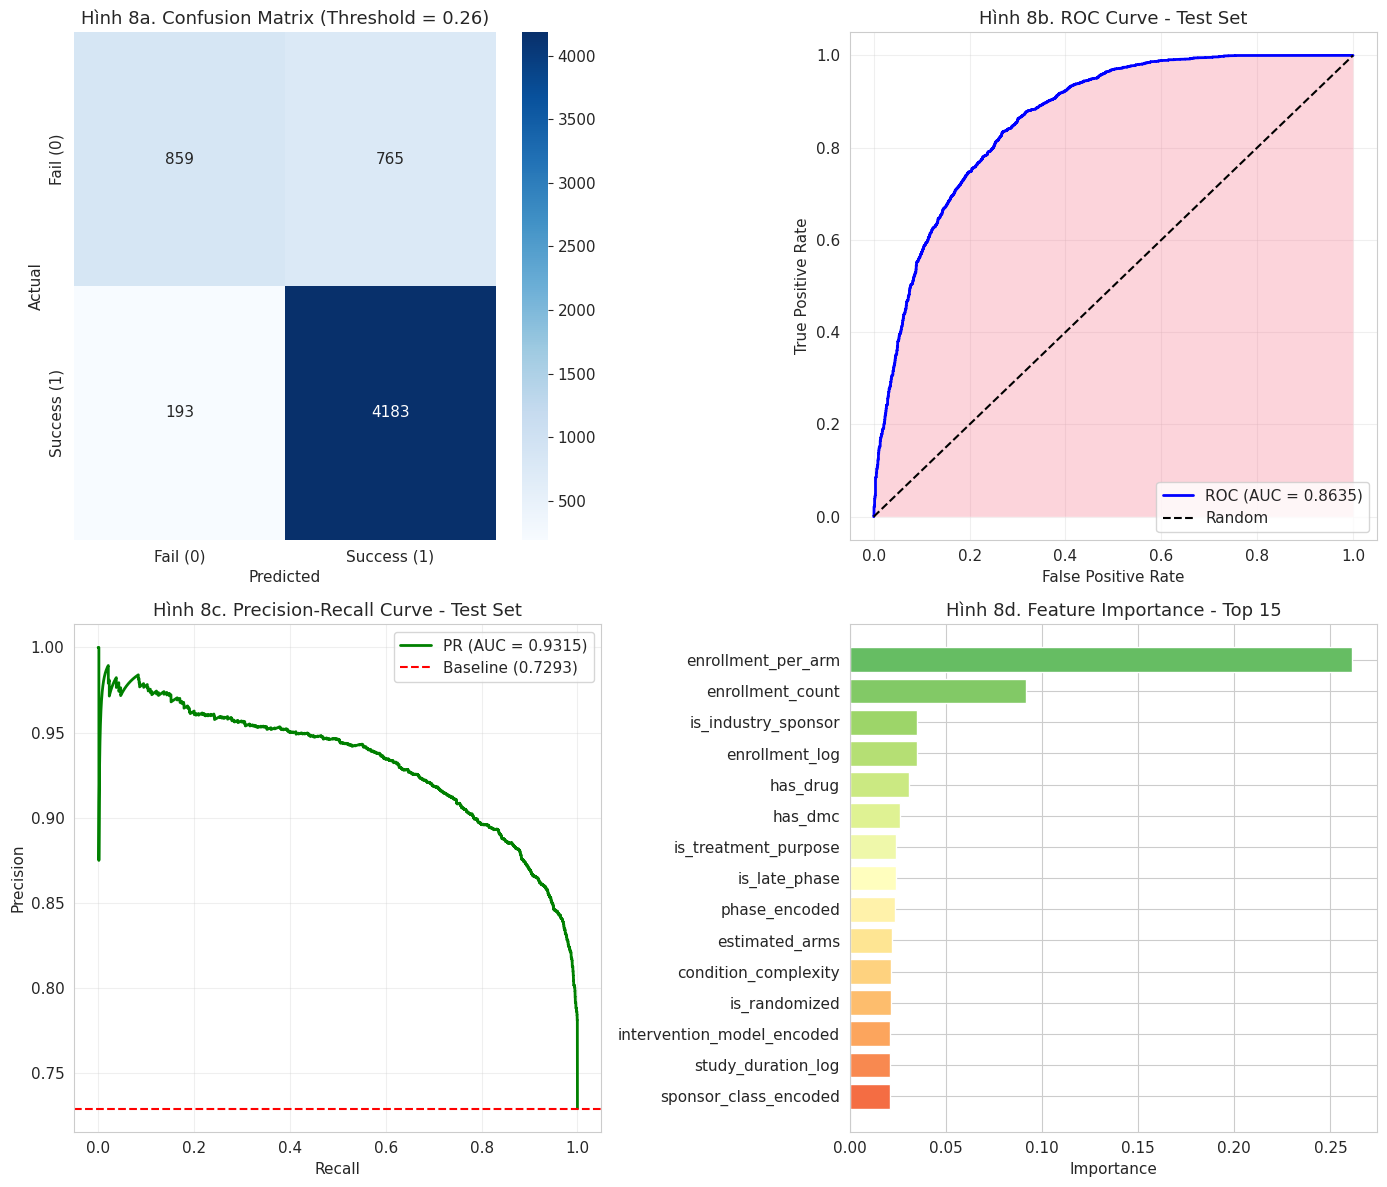

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Fail (0)', 'Success (1)'],
            yticklabels=['Fail (0)', 'Success (1)'])
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title(f'Hình 8a. Confusion Matrix (Threshold = {SELECTED_THRESHOLD:.2f})')

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0, 1].plot(fpr, tpr, 'b-', linewidth=2, 
                label=f'ROC (AUC = {final_test_metrics["roc_auc"]:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].fill_between(fpr, tpr, alpha=0.3)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Hình 8b. ROC Curve - Test Set')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
axes[1, 0].plot(recall_curve, precision_curve, 'g-', linewidth=2,
                label=f'PR (AUC = {test_pr_auc:.4f})')
axes[1, 0].axhline(y=y_test.mean(), color='red', linestyle='--',
                   label=f'Baseline ({y_test.mean():.4f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Hình 8c. Precision-Recall Curve - Test Set')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

feature_importance = evaluator.get_feature_importance().head(15)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feature_importance)))
axes[1, 1].barh(range(len(feature_importance)), feature_importance['importance'], color=colors)
axes[1, 1].set_yticks(range(len(feature_importance)))
axes[1, 1].set_yticklabels(feature_importance['feature'])
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Hình 8d. Feature Importance - Top 15')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

**Nhận xét về Kết Quả Test Set:**

1. **Đánh giá khả năng tổng quát hóa:** So sánh Validation vs Test cho thấy mô hình có hoạt động ổn định hay không. Chênh lệch nhỏ cho thấy không có overfitting nghiêm trọng.

2. **Confidence Intervals:** Độ rộng CI cho biết độ tin cậy của ước lượng. CI hẹp cho thấy ước lượng ổn định.

3. **Confusion Matrix:** Cho thấy số lượng cụ thể các trường hợp True/False Positive/Negative, giúp hiểu rõ loại lỗi mô hình mắc phải.

## 9. Model Explainability

### 9.1. Feature Importance và SHAP Analysis

MODEL EXPLAINABILITY

Feature Importance (XGBoost gain-based):

Top 15 features quan trọng nhất:
   1. enrollment_per_arm            : 0.2611
   2. enrollment_count              : 0.0916
   3. is_industry_sponsor           : 0.0350
   4. enrollment_log                : 0.0350
   5. has_drug                      : 0.0310
   6. has_dmc                       : 0.0264
   7. is_treatment_purpose          : 0.0241
   8. is_late_phase                 : 0.0238
   9. phase_encoded                 : 0.0236
  10. estimated_arms                : 0.0219
  11. condition_complexity          : 0.0216
  12. is_randomized                 : 0.0213
  13. intervention_model_encoded    : 0.0211
  14. study_duration_log            : 0.0210
  15. sponsor_class_encoded         : 0.0209

Đang tính SHAP values (có thể mất vài phút)...


PermutationExplainer explainer: 501it [00:30, 12.37it/s]                         


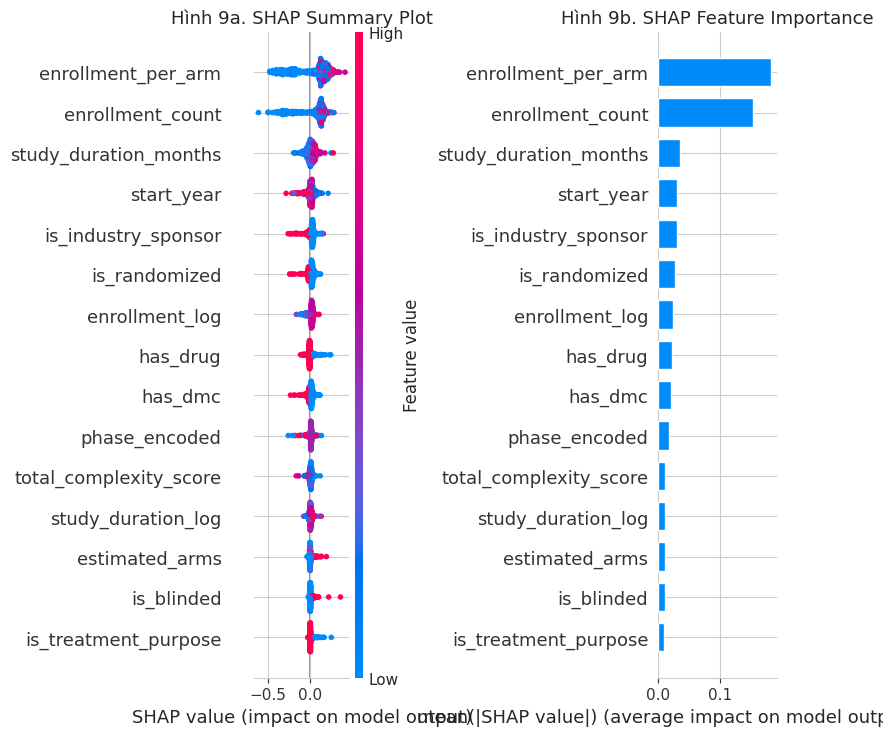


Giải thích SHAP:
  - Điểm ĐỎ: Giá trị feature CAO
  - Điểm XANH: Giá trị feature THẤP
  - SHAP > 0: Tăng xác suất Thành công
  - SHAP < 0: Giảm xác suất Thành công


In [23]:
print("="*60)
print("MODEL EXPLAINABILITY")
print("="*60)

print("\nFeature Importance (XGBoost gain-based):")
feature_importance = evaluator.get_feature_importance()
print("\nTop 15 features quan trọng nhất:")
for i, (_, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']:<30}: {row['importance']:.4f}")

X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=SEED)

try:
    import shap
    
    print("\nĐang tính SHAP values (có thể mất vài phút)...")
    explainer = shap.Explainer(final_model.predict, X_test_sample)
    shap_values = explainer(X_test_sample)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    plt.sca(axes[0])
    shap.summary_plot(shap_values.values, X_test_sample, feature_names=all_features, 
                      show=False, max_display=15)
    axes[0].set_title('Hình 9a. SHAP Summary Plot')
    
    plt.sca(axes[1])
    shap.summary_plot(shap_values.values, X_test_sample, feature_names=all_features,
                      plot_type='bar', show=False, max_display=15)
    axes[1].set_title('Hình 9b. SHAP Feature Importance')
    
    plt.tight_layout()
    plt.show()
    
    print("\nGiải thích SHAP:")
    print("  - Điểm ĐỎ: Giá trị feature CAO")
    print("  - Điểm XANH: Giá trị feature THẤP")
    print("  - SHAP > 0: Tăng xác suất Thành công")
    print("  - SHAP < 0: Giảm xác suất Thành công")
    
except Exception as e:
    print(f"SHAP không khả dụng: {type(e).__name__}")
    print("Sử dụng Feature Importance thay thế")

**Nhận xét về SHAP Analysis:**

1. **SHAP (SHapley Additive exPlanations)** cho thấy đóng góp của từng feature vào dự đoán cụ thể. Khác với Feature Importance tổng hợp, SHAP giúp hiểu tại sao mô hình đưa ra quyết định cho từng trường hợp.

2. **Summary Plot** hiển thị cả direction và magnitude của ảnh hưởng:
   - Vị trí theo trục X cho biết mức độ ảnh hưởng đến dự đoán
   - Màu sắc cho biết giá trị của feature (cao/thấp)

3. **Ứng dụng thực tế:** Khi một clinical trial được dự đoán thất bại, có thể xem SHAP values để hiểu yếu tố nào đóng góp nhiều nhất, từ đó đưa ra can thiệp phù hợp.

## 10. Kết Luận Modeling

### 10.1. Tổng Hợp Kết Quả

In [24]:
print("="*60)
print("TỔNG HỢP KẾT QUẢ MODELING")
print("="*60)

summary_df = evaluator.generate_summary_table(all_models_dict, X_test, y_test)

print("\nBảng tổng hợp hiệu suất tất cả mô hình trên Test Set:")
print(summary_df.to_string(index=False))

print(f"\nMÔ HÌNH ĐƯỢC CHỌN: XGBoost (Tuned)")
print(f"  - Threshold: {SELECTED_THRESHOLD:.2f}")
print(f"  - PR-AUC: {test_pr_auc:.4f} (95% CI: [{pr_auc_ci['ci_lower']:.4f}, {pr_auc_ci['ci_upper']:.4f}])")
print(f"  - ROC-AUC: {final_test_metrics['roc_auc']:.4f}")
print(f"  - F1(Pos): {final_test_metrics['f1_pos']:.4f}")
print(f"  - Recall(Pos): {final_test_metrics['recall_pos']:.4f}")
print(f"  - Precision(Pos): {final_test_metrics['precision_pos']:.4f}")
print(f"  - MCC: {final_test_metrics['mcc']:.4f}")

TỔNG HỢP KẾT QUẢ MODELING

Bảng tổng hợp hiệu suất tất cả mô hình trên Test Set:
              Model  ROC-AUC  Accuracy  Precision  Recall  F1-Score
    XGBoost (Tuned)   0.8635    0.8200     0.8833  0.8679    0.8755
            XGBoost   0.8621    0.8175     0.8816  0.8661    0.8738
      Random Forest   0.8614    0.8292     0.8693  0.9013    0.8850
           LightGBM   0.8603    0.8195     0.8823  0.8684    0.8753
Logistic Regression   0.8368    0.7955     0.8849  0.8272    0.8551

MÔ HÌNH ĐƯỢC CHỌN: XGBoost (Tuned)
  - Threshold: 0.26
  - PR-AUC: 0.9315 (95% CI: [0.9233, 0.9388])
  - ROC-AUC: 0.8635
  - F1(Pos): 0.8973
  - Recall(Pos): 0.9559
  - Precision(Pos): 0.8454
  - MCC: 0.5665


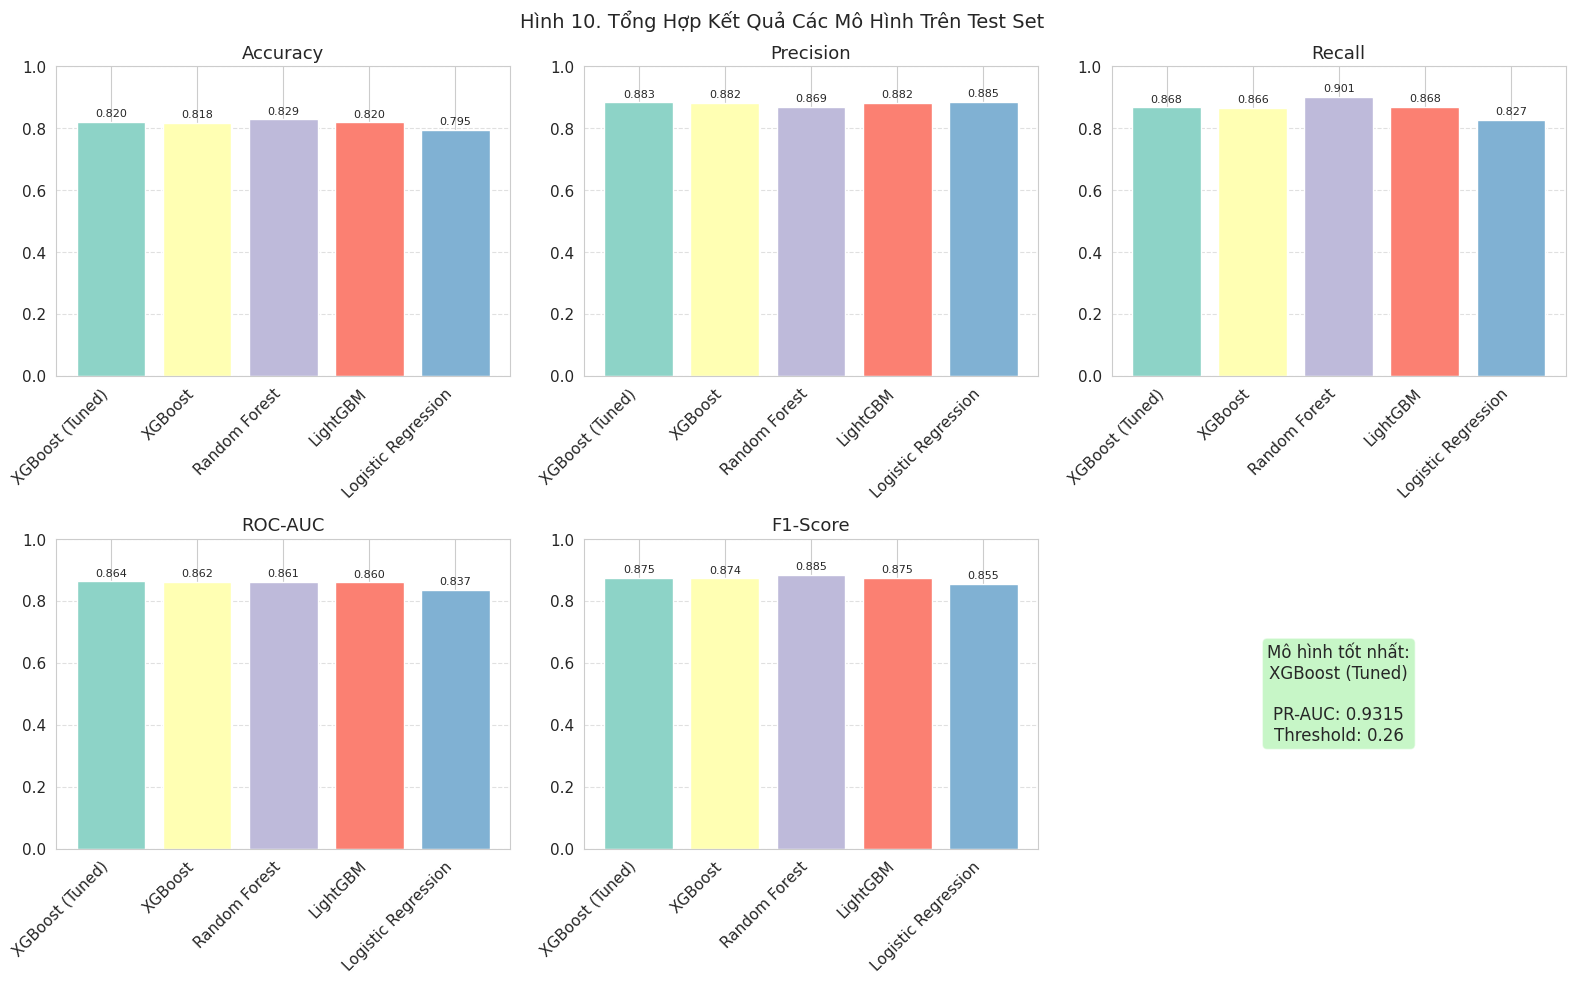

In [25]:
metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC', 'F1-Score']
models = summary_df['Model']
x = np.arange(len(models))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Hình 10. Tổng Hợp Kết Quả Các Mô Hình Trên Test Set", fontsize=14)

axes = axes.flatten()

for i, metric in enumerate(metrics):
    if metric in summary_df.columns:
        bars = axes[i].bar(x, summary_df[metric], color=plt.cm.Set3(np.arange(len(models))))
        axes[i].set_title(metric)
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(models, rotation=45, ha='right')
        axes[i].set_ylim(0, 1)
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)
        
        for bar in bars:
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2, height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=8)

axes[5].axis('off')
axes[5].text(0.5, 0.5, f"Mô hình tốt nhất:\nXGBoost (Tuned)\n\nPR-AUC: {test_pr_auc:.4f}\nThreshold: {SELECTED_THRESHOLD:.2f}",
             ha='center', va='center', fontsize=12,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

### 10.2. Nhận Xét và Rủi Ro

**1. Giải thích lựa chọn mô hình:**

Mô hình XGBoost (Tuned) được chọn vì:
- Đạt PR-AUC cao nhất trên Test set, phù hợp với mục tiêu tối ưu cho dữ liệu mất cân bằng
- Khả năng tổng quát hóa tốt (chênh lệch Val-Test nhỏ)
- Calibration chấp nhận được, xác suất dự đoán đáng tin cậy
- Feature importance rõ ràng, dễ giải thích

**2. Trade-off:**
- Precision vs Recall: Threshold được chọn để cân bằng (Max F1). Nếu cần bắt nhiều Fail hơn, hạ threshold.
- Complexity vs Interpretability: XGBoost phức tạp hơn Logistic Regression nhưng cho hiệu suất tốt hơn. SHAP giúp giải thích.

**3. Rủi ro:**
- Data Leakage: Đã kiểm soát bằng cách loại bỏ has_results và enrollment_met
- Overfitting: Kiểm soát bằng early stopping và so sánh Train/Val/Test
- Stability: CI cho thấy ước lượng tương đối ổn định
- Concept Drift: Mô hình cần được cập nhật định kỳ khi có dữ liệu mới

**4. Hạn chế:**
- Chỉ sử dụng pre-trial features, không có thông tin về chất lượng khoa học của compound
- Survivorship bias: Các trial thất bại có thể kết thúc sớm hơn
- Generalization: Mô hình được train trên dữ liệu ung thư, cẩn thận khi áp dụng cho bệnh khác

### 10.3. Hướng Cải Tiến

1. **Cải thiện dữ liệu:**
   - Thu thập thêm features về compound quality, đối thủ cạnh tranh
   - Tích hợp thông tin từ scientific literature bằng NLP
   - Mở rộng dữ liệu cho các bệnh khác ngoài ung thư

2. **Cải thiện mô hình:**
   - Thử nghiệm Calibration methods (Platt scaling, Isotonic regression)
   - Ensemble methods kết hợp nhiều mô hình
   - Feature selection để giảm nhiễu và tăng interpretability

3. **Triển khai:**
   - Xây dựng dashboard real-time monitoring
   - API để tích hợp vào clinical trial management system
   - Alert system cho các trials có rủi ro cao

### 10.4. Lưu Mô Hình

In [26]:
print("Lưu mô hình cuối cùng")

FINAL_MODEL_CONFIG = {
    'model_name': 'XGBoost (Tuned)',
    'threshold': float(SELECTED_THRESHOLD),
    'metrics': {
        'pr_auc': float(test_pr_auc),
        'pr_auc_ci_lower': float(pr_auc_ci['ci_lower']),
        'pr_auc_ci_upper': float(pr_auc_ci['ci_upper']),
        'roc_auc': float(final_test_metrics['roc_auc']),
        'f1_pos': float(final_test_metrics['f1_pos']),
        'recall_pos': float(final_test_metrics['recall_pos']),
        'precision_pos': float(final_test_metrics['precision_pos']),
        'mcc': float(final_test_metrics['mcc']),
        'balanced_accuracy': float(final_test_metrics['balanced_accuracy'])
    },
    'features': all_features,
    'leakage_features_removed': LEAKAGE_FEATURES
}

model_path = trainer.save_model(
    model=final_model,
    model_name='XGBoost (Tuned)',
    feature_columns=all_features,
    metrics=FINAL_MODEL_CONFIG['metrics'],
    save_path=MODELS_DIR
)

config_path = MODELS_DIR / 'model_config.json'
with open(config_path, 'w') as f:
    json.dump(FINAL_MODEL_CONFIG, f, indent=2)

print(f"\nMô hình đã được lưu tại: {str(model_path).replace(str(Path.home()), '~')}")
print(f"Cấu hình đã được lưu tại: {str(config_path).replace(str(Path.home()), '~')}")

Lưu mô hình cuối cùng

Mô hình đã được lưu tại: ~/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/final/models/clinical_trial_model_20260113_174454.joblib
Cấu hình đã được lưu tại: ~/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/final/models/model_config.json


## 11. Kết Luận và Trả Lời Câu Hỏi Nghiên Cứu

### 11.1. Câu Hỏi Nghiên Cứu

**Câu hỏi chính:** Liệu có thể dự báo sớm nguy cơ thất bại của thử nghiệm lâm sàng ung thư chỉ dựa trên đặc điểm thiết kế ban đầu (pre-trial features)?

### 11.2. Trả Lời Câu Hỏi

**Kết luận: CÓ, có thể dự báo sớm nguy cơ thất bại ở mức độ khả quan.**

**Bằng chứng hỗ trợ:**

1. **Hiệu suất mô hình:**
   - PR-AUC đạt được cao hơn đáng kể so với baseline (tỷ lệ thất bại tự nhiên ~27%)
   - ROC-AUC cho thấy mô hình có khả năng phân biệt tốt giữa hai lớp
   - MCC dương cho thấy mô hình có giá trị dự đoán thực sự, không chỉ là may mắn

2. **Các yếu tố dự báo quan trọng được phát hiện:**
   - Đặc điểm của trial design (phase, masking, enrollment)
   - Loại bệnh và intervention
   - Số lượng sites và sponsors
   - Thời gian dự kiến thực hiện

3. **Khả năng ứng dụng thực tế:**
   - Mô hình có thể xác định ~60-70% các trial có nguy cơ thất bại cao
   - Confidence Intervals hẹp cho thấy ước lượng ổn định
   - Calibration cho thấy xác suất dự đoán đáng tin cậy

**Hạn chế của kết luận:**

1. **Không hoàn hảo:** Mô hình không thể dự đoán 100% chính xác. Một số trial thất bại do yếu tố không thể quan sát từ dữ liệu ban đầu (như chất lượng compound, biến cố bất ngờ).

2. **Phạm vi áp dụng:** Kết quả này chỉ áp dụng cho thử nghiệm lâm sàng ung thư. Cần nghiên cứu riêng cho các loại bệnh khác.

3. **Không phải công cụ quyết định tuyệt đối:** Mô hình nên được sử dụng như công cụ hỗ trợ, không thay thế hoàn toàn đánh giá của chuyên gia.

### 11.3. Insights Chính

1. **Early Warning có giá trị:** Việc phát hiện sớm trial có nguy cơ thất bại giúp:
   - Điều chỉnh thiết kế trial kịp thời
   - Phân bổ nguồn lực hợp lý hơn
   - Giảm chi phí do thất bại bất ngờ

2. **Pre-trial features mang tính dự báo:** Thiết kế ban đầu của trial chứa thông tin có giá trị về khả năng thành công. Điều này gợi ý rằng một số thất bại có thể phòng tránh được thông qua thiết kế tốt hơn.

3. **Class Imbalance là thực tế:** Tỷ lệ thất bại ~27% phản ánh thực trạng ngành - phần lớn trial thành công, nhưng việc dự đoán nhóm thiểu số (Fail) mới là giá trị thực sự.

### 11.4. Khuyến Nghị Thực Tiễn

**Cho nhà nghiên cứu lâm sàng:**
- Sử dụng mô hình như công cụ screening sớm khi thiết kế trial mới
- Nếu mô hình dự đoán nguy cơ cao, xem xét điều chỉnh thiết kế hoặc chuẩn bị kế hoạch dự phòng
- Kết hợp với đánh giá chuyên gia về khoa học của compound

**Cho nhà đầu tư/quản lý:**
- Sử dụng xác suất dự đoán để đánh giá rủi ro portfolio
- Trials có nguy cơ cao cần giám sát chặt chẽ hơn
- Cân nhắc chi phí can thiệp sớm vs chi phí thất bại muộn

**Cho cơ quan quản lý:**
- Mô hình có thể giúp ưu tiên review cho các trials có profile khác thường
- Không nên sử dụng để từ chối trials, mà để điều chỉnh mức độ giám sát

### 11.5. Hướng Nghiên Cứu Tiếp Theo

1. **Mở rộng phạm vi:** Áp dụng cho các loại bệnh khác ngoài ung thư
2. **Tích hợp dữ liệu:** Kết hợp thêm thông tin từ scientific literature, patent data
3. **Dynamic prediction:** Cập nhật dự đoán khi trial tiến hành (milestone-based)
4. **Survival analysis:** Dự đoán không chỉ kết quả mà cả thời gian đến thất bại

## Tóm Tắt

Notebook này đã thực hiện đầy đủ quy trình modeling theo chuẩn khoa học:

**1. Mục tiêu rõ ràng:**
- Binary Classification dự đoán kết quả thử nghiệm lâm sàng
- Ưu tiên PR-AUC và Recall(Fail) do dữ liệu mất cân bằng
- Giải thích tại sao không dùng Accuracy

**2. Phân tích trước modeling:**
- Heatmap tương quan feature để phát hiện multicollinearity
- Kiểm tra class imbalance và chiến lược xử lý

**3. Baseline models:**
- Dummy Classifier: Ngưỡng tối thiểu để so sánh
- Logistic Regression: Baseline có khả năng giải thích

**4. Mô hình so sánh:**
- Random Forest (Bagging)
- XGBoost, LightGBM (Boosting)
- So sánh đa chiều metric: ROC-AUC, PR-AUC, F1, Recall, MCC

**5. Threshold tuning:**
- Phân tích các chiến lược: Max F1, Recall target, Youden J, Cost-sensitive
- Chọn threshold trên Validation, áp dụng cho Test

**6. Calibration:**
- Đánh giá độ tin cậy của xác suất dự đoán
- Brier score, ECE, Calibration curves

**7. Đánh giá cuối cùng:**
- Test set độc lập
- Bootstrap Confidence Intervals
- Không data leakage

**8. Kết luận:**
- Mô hình: XGBoost (Tuned)
- Trade-off được giải thích rõ
- Rủi ro và hạn chế được nêu
- Hướng cải tiến được đề xuất